# Small-Fleet Trucking Rater

A rater for for-hire trucking, 1–5 power unit fleets, primary auto liability: submission in,
bindable premium (or a defensible decline) out, priced off an explicit loss-cost-plus-margin view
built from FMCSA Census and Crash data.

## What this notebook does

1. Pulls a calibration population of small-fleet carriers from FMCSA Census and matches 3 years of
   crash history from the FMCSA Crash file (Steps 1–13).
2. Builds a portfolio-calibrated, credibility-weighted frequency model restricted to the 1–5
   power-unit target segment (Steps 14–17).
3. Takes a **submission** (USDOT number, drivers, power units, VINs, radius, commodity) and merges
   it with the FMCSA-derived facts to build a per-carrier profile, cross-checking declared figures
   against FMCSA and rating off the larger of the two (Steps 18, 21–22).
4. Prices the submission off an expected loss cost (frequency × a radius/commodity/hazmat-adjusted
   dollar severity), loaded for expenses and profit into a bindable premium (Steps 19, 23–24).
5. Applies underwriting rules — DECLINE (hard stop), REFER (needs manual review), or ACCEPT — kept
   separate from pricing (Step 20).
6. Wraps all of the above into one `rate_carrier(submission)` function with structured error
   handling, and a `run_book_check(submissions)` command that reports priced/referred/declined
   counts, decline rate, premium distribution, and any errors across a batch (Steps 25–27).
7. The frequency component has been rebuilt as a **Poisson/Negative-Binomial GLM** with a
   `log(exposure)` offset, blended with the carrier's own experience by credibility
   (Steps 17A–17J). A portfolio-average + credibility engine (the prior method) is **retained as a
   fallback and comparison baseline** — set `FREQUENCY_METHOD = "legacy"` in Step 2b —
   so the two can be compared on the same submissions (Step 27b). Severity, expenses, margin and the
   underwriting rules are unchanged, so any premium movement is attributable to the
   frequency model alone.

---

## Repository layout

```
USTruckRater_Final.ipynb   <- this notebook (narrative + model)
  socrata_api.py       generic Socrata/data.gov API helpers (retries, counting,
                        a filter fallback ladder, join-key normalisation)
  glm_engine.py         Poisson/Negative-Binomial GLM fitting engine
                        (statsmodels, with a NumPy IRLS fallback)
  legacy_frequency.py    the retained portfolio-credibility frequency factor
Audit_Trail.docx        version history and judgment-call log
```

The notebook contains the core modelling and pricing methodology. Supporting API, GLM fallback and legacy frequency code is kept in separate Python modules in the same folder to keep the notebook concise and reproducible.

## Contents

**Setup**
Step 2 Configuration · Step 3 API helper · Step 4 Schema inspection · Step 5 Field mapping

**Data pipeline**
Step 6 Retrieve Census carriers · Step 7 Clean Census data · Step 8 Power-unit diagnostic ·
Step 9 Retrieve crash data · Step 10 Deduplicate crashes · Step 11 3-year carrier experience ·
Step 12 Severity indicators · Step 13 Data quality check · Step 14 Calibration population ·
Step 15 Exposure/crash diagnostics

**Frequency models**
Step 16 Legacy credibility frequency (retained) · Step 17 Age relativities (exploratory) ·
**Step 17A-17H — GLM frequency model** (dataset → engine → fit → overdispersion →
relativity review → validation → GLM-vs-legacy → credibility blend)

**Rating and underwriting**
Step 18 Prospective risk relativities · Step 19 Severity dollar index ·
Step 20 Underwriting rules · Step 21 Example submissions ·
Step 22 Carrier profile lookup · Step 23 Rating factors → expected loss cost ·
Step 24 Premium calculation · Step 25 Final rater · Step 26 Quote summary

**Book check**
Step 27 Self-running book check · Step 27b Book check, both pricing approaches compared

**Outputs & writeup**
Step 28 Save outputs · Methodology, diagnostics and limitations ·
Final model interpretation · Trends & analysis


# Setup

### Importing Libraries

In [3]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("Packages loaded.")


Packages loaded.


### Loading Datasets and Setting up Parameters

In [2]:
# STEP 2 — Configuration

CENSUS_URL = "https://data.transportation.gov/resource/az4n-8mr2.json"
CRASH_URL  = "https://data.transportation.gov/resource/aayw-vxb3.json"

# Calibration sample size
CALIBRATION_CARRIERS = 50_000

# Experience period.
EXPERIENCE_YEARS = 3

# ---------------------------------------------------------
# Premium build — loss-cost-plus-margin
# ---------------------------------------------------------
# Baseline severity assumption.
# $75,000 is a judgmental prototype assumption rather than an estimate derived from the FMCSA data.
# Severity calibration is therefore a key limitation of the current pricing model.
BASE_SEVERITY_DOLLARS = 75_000  # PLACEHOLDER -- source and cite before use

EXPENSE_LOAD = 0.15 #Fixed Exp + Variable Exp
PROFIT_LOAD = 0.10

MIN_PREMIUM = 500 #underwriting guardrail

# Credibility parameter for frequency (portfolio calibration).
CREDIBILITY_WEIGHT = 10

# Credibility parameter for severity (own-record vs prior).
# K = crash count at which observed severity gets 50% weight.
SEVERITY_CREDIBILITY_K = 3

# Severity outcome weights -- a defensible starting point to document and
# revisit, not an FMCSA-published figure. Every DOT-recordable crash involves
# at least a tow-away, injury, or fatality -- there is no "clean" crash tier in
# this data, so tow-away is the floor severity, not the absence of a crash.
# fatal > injury > tow-away.
SEVERITY_WEIGHT_FATAL = 10
SEVERITY_WEIGHT_INJURY = 3
SEVERITY_WEIGHT_TOW_AWAY = 1

# Assumption for a carrier with NO crash history: "a typical unknown crash
# is a tow-away-only crash (no injury, no fatality) -- the floor severity."
# Replace with an actual book average once enough submissions have gone
# through the rater to compute one.
PRIOR_SEVERITY_INDEX = SEVERITY_WEIGHT_TOW_AWAY

# ---------------------------------------------------------
# Radius / commodity / hazmat relativities
# ---------------------------------------------------------
# Judgment calls, not fitted or FMCSA-provided -- documented here so they
# can be defended and revisited once real experience is available.
#
# --- Severity relativities ---
# Speed/impact-force story: long-haul crashes happen at highway speed and
# tend to be worse; hazmat and refrigerated cargo raise the liability/
# cleanup/spoilage cost once a crash happens.
SEVERITY_RADIUS_RELATIVITY = {
    "Intrastate": 0.90,
    "Regional": 1.00,
    "Long-haul": 1.20,
}

SEVERITY_COMMODITY_RELATIVITY = {
    "General freight": 1.00,
    "Building materials": 1.10,
    "Refrigerated": 1.20,
    "Hazardous materials": 1.35,
}

SEVERITY_HAZMAT_MULTIPLIER = 1.15  # extra severity load if Census confirms HM registration

# --- Frequency relativities ---
# Exposure/driving-conditions story: intrastate and building-materials work
# mean more stop-start, urban, and job-site driving per mile -- more chances
# to have *a* crash, even a mild one. Long-haul is comparatively monotonous
# highway mileage -- fewer crashes per unit, but worse when one happens
# (already captured on the severity side above, not double-counted here).
# Hazmat carriers face stricter FMCSA driver/vehicle oversight (endorsements,
# inspections), which plausibly lowers frequency even though severity is
# higher when a hazmat crash does occur.
FREQUENCY_RADIUS_RELATIVITY = {
    "Intrastate": 1.10,
    "Regional": 1.00,
    "Long-haul": 0.95,
}

FREQUENCY_COMMODITY_RELATIVITY = {
    "General freight": 1.00,
    "Building materials": 1.15,
    "Refrigerated": 1.10,
    "Hazardous materials": 0.90,
}

FREQUENCY_HAZMAT_MULTIPLIER = 0.95  # frequency discount for stricter hazmat oversight

# The severity and frequency tables must cover the same categories -- an
# unrecognized radius/commodity value should be caught once by underwriting
# (Step 20), not silently default to 1.0 on one side and get flagged on the
# other.
assert set(SEVERITY_RADIUS_RELATIVITY) == set(FREQUENCY_RADIUS_RELATIVITY), \
    "radius relativity tables must cover the same categories"
assert set(SEVERITY_COMMODITY_RELATIVITY) == set(FREQUENCY_COMMODITY_RELATIVITY), \
    "commodity relativity tables must cover the same categories"

# ---------------------------------------------------------
# Underwriting thresholds
# ---------------------------------------------------------
# Prototype frequency referral threshold.
# This is deliberately NOT a final actuarial threshold.
FREQUENCY_REFERRAL_MULTIPLE = 3.0

# How far a declared power-unit/driver count can differ from the FMCSA
# record before it becomes an underwriting flag.
DECLARED_VS_FMCSA_TOLERANCE = 0.30  # 30%

# Target segment for calibration. The brief scopes this rater to 1-5
# power unit carriers -- calibrate frequency on that same segment, not
# on the full mixed-fleet-size Census pull.
TARGET_PU_MIN = 1
TARGET_PU_MAX = 5

# The carrier to quote (single-carrier smoke test in Step 25) is set as
# MAIN_SUBMISSION in Step 21, not here -- that's where its full submission
# details (drivers, power_units, radius, commodity, VINs) live too.

REQUEST_TIMEOUT = 60
API_RETRIES = 3

print("Configuration loaded.")


# =========================================================
# STEP 2b — GLM frequency configuration
# =========================================================
# Configuration for the GLM frequency model (Steps 17A-17H). The legacy
# credibility settings (CREDIBILITY_WEIGHT) are retained so the portfolio-
# credibility and GLM approaches can be run side by side in the book-check
# comparison (Step 27b).

# Which frequency engine the rater prices off.
#   "legacy"          -- Step 16 portfolio + credibility relativity (original build)
#   "glm"             -- pure GLM expected frequency, no own-experience weight
#   "glm_credibility" -- Z x own history + (1-Z) x GLM  (the selected method)
FREQUENCY_METHOD = "glm_credibility"

# --- Exposure definition -------------------------------------------------
# Exposure base = power units x years on risk, in unit-years.
# A carrier registered 8 months ago has NOT been exposed for the full 3-year
# window, so charging it the full 3 unit-years of exposure understates its
# frequency. We cap years-on-risk at the carrier's own age. This is a
# judgment call: it stops the "new carrier" age coefficient from being a
# pure data artefact of a short lookback. Set to False to use a flat
# EXPERIENCE_YEARS for every carrier.
USE_AGE_CAPPED_EXPOSURE = True
MIN_EXPOSURE_YEARS = 0.5      # floor, so a brand-new carrier can't get near-zero exposure
MAX_PLAUSIBLE_CRASHES_3YR = 50  # data-quality cap: above this for a 1-5 PU fleet is a bad record

# --- Feature engineering bounds -----------------------------------------
DRIVERS_PER_UNIT_MIN = 0.25   # clip: fewer than 1 driver per 4 trucks is a data error
DRIVERS_PER_UNIT_MAX = 4.00   # clip: team/relay driving tops out around here for small fleets
DRIVERS_PER_UNIT_DEFAULT = 1.0  # used when drivers are missing (flagged separately)
MIN_LEVEL_UNIT_YEARS = 250    # categorical levels thinner than this get lumped into "Other"

# --- Fitting / selection -------------------------------------------------
GLM_TEST_FRACTION = 0.30
GLM_RANDOM_SEED = 42
OVERDISPERSION_THRESHOLD = 1.25   # Pearson chi2/df above this -> test Negative Binomial
NB_ALPHA_GRID = [0.10, 0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00, 5.00]
GLM_AIC_IMPROVEMENT_MIN = 4.0     # NB must beat Poisson AIC by this much to be selected

# --- Credibility blend on top of the GLM --------------------------------
# Z = unit-years / (unit-years + GLM_CREDIBILITY_K).
# K is in UNIT-YEARS (the legacy CREDIBILITY_WEIGHT=10 was in power units,
# which is the same number on a 3-year window only by coincidence -- they
# are not interchangeable, hence a separate parameter).
# K = 10 unit-years gives a 1-PU carrier with 3 years of history Z = 0.23:
# its own record moves the price, but one crash doesn't triple it.
GLM_CREDIBILITY_K = 10.0

# Cap on how far the blended frequency can sit from the GLM expectation.
# Mirrors the legacy 0.50-3.00 relativity clamp so the two methods are
# guardrailed on the same basis.
GLM_BLEND_FLOOR_MULTIPLE = 0.50
GLM_BLEND_CAP_MULTIPLE = 3.00

# --- Double-count control ------------------------------------------------
# The GLM fits hazmat registration and interstate/intrastate operation from
# actual history. The judgmental Step 18 frequency table ALSO loads hazmat
# and (via radius) intrastate operation. Applying both would charge the same
# signal twice, so in GLM mode the overlapping judgmental pieces are
# neutralised and only the genuinely un-modelled part of radius/commodity is
# retained. Radius and commodity as declared on the submission do not exist
# in the FMCSA training data, so they stay judgmental -- clearly labelled.
APPLY_JUDGMENTAL_HAZMAT_FREQ_IN_GLM_MODE = False

# Intrastate is set to 1.00 here because operation_group in the GLM already
# carries interstate vs intrastate. Long-haul keeps its judgmental discount:
# haul length within interstate operation is NOT in the training data.
FREQUENCY_RADIUS_RELATIVITY_GLM = {
    "Intrastate": 1.00,   # neutralised -- captured by operation_group in the GLM
    "Regional": 1.00,
    "Long-haul": 0.95,    # judgmental, retained
}

assert set(FREQUENCY_RADIUS_RELATIVITY_GLM) == set(FREQUENCY_RADIUS_RELATIVITY), \
    "GLM-mode radius table must cover the same categories as the legacy table"

# =========================================================
# STEP 2c — Calibration sampling (stratified pull)
# =========================================================
# Socrata returns rows in DOT-number order by default, so an unordered pull
# is dominated by the OLDEST registrations in the file rather than a
# cross-section of the market. That understates carrier-age variation,
# over-represents dormant/defunct registrations, and biases measured crash
# frequency well below published FMCSA statistics for for-hire operations --
# the model would end up fitting "is this carrier still operating" rather
# than "how risky is this carrier".
#
# Three controls address this:
#   1. Filter to ACTIVE carriers server-side (status_code = 'A').
#   2. Filter to the 1-5 power-unit target segment server-side, so the whole
#      pull is usable calibration data rather than mostly discarded in Step 14.
#   3. STRATIFY the pull across the DOT-number range instead of taking the
#      front of the file, so every registration vintage is represented and
#      carrier age actually varies.

# Restrict to active carriers. Set to None to disable (e.g. if this vintage of
# the Census file doesn't expose status_code).
CENSUS_STATUS_FILTER = "A"

# Pull the target segment directly rather than filtering after the fact.
CENSUS_FILTER_TO_TARGET_PU = True

# Number of strata spread evenly across the DOT-number range. More strata =
# better vintage coverage, more API calls. 10 is a reasonable prototype value.
CENSUS_SAMPLE_STRATA = 10

# =========================================================
# STEP 2d — Credibility blend balance
# =========================================================
# The 0.50x-3.00x clamp around the GLM expectation is asymmetric in aggregate:
# zero-claim carriers get lifted to the floor while carriers with a crash on a
# thin exposure base have most of their experience truncated at the cap. Left
# uncorrected, this can leave the exposure-weighted blended frequency
# materially (in testing, ~33%) below the observed portfolio frequency --
# i.e. the whole book underpriced by a guardrail.
#
# Credibility blending is only balanced in aggregate if it isn't capped. So we
# cap (to stop any single risk getting an indefensible price), then rebalance
# the whole book back to the observed portfolio frequency with a single
# off-balance factor. This is standard ratemaking practice and it is applied
# transparently -- the factor is printed and saved.
REBALANCE_BLEND_CAP = True

# Populated in Step 17H once the model is fitted. 1.0 = no correction.
BLEND_OFF_BALANCE_FACTOR = 1.0

print("GLM frequency configuration loaded. FREQUENCY_METHOD =", FREQUENCY_METHOD)


Configuration loaded.
GLM frequency configuration loaded. FREQUENCY_METHOD = glm_credibility


## Step 3 — API Helper & Shared Utilities

In [8]:
# STEP 3 — API helper & shared utilities
# The retry loop, counting and join-key logic are generic Socrata plumbing --
# see lib/socrata_api.py. api_get() keeps its original (url, params) call
# signature so every other cell that calls it is unchanged.

from socrata_api import make_session, api_get as _socrata_get, standardize_join_key

session = make_session("FMCSA-Trucking-Rater-Prototype/1.0")

def api_get(url, params, retries=API_RETRIES):
    """Retrieve JSON from the FMCSA/Socrata API with retries."""
    return _socrata_get(session, url, params, retries=retries, timeout=REQUEST_TIMEOUT)

standardize_dot_key = standardize_join_key

## Step 4 — Schema Inspection

In [9]:
# STEP 4 — Inspect the live API schemas

census_sample = pd.DataFrame(
    api_get(
        CENSUS_URL,
        {"$limit": 1}
    )
)

crash_sample = pd.DataFrame(
    api_get(
        CRASH_URL,
        {"$limit": 1}
    )
)

census_sample.columns = [
    str(c).strip().lower()
    for c in census_sample.columns
]

crash_sample.columns = [
    str(c).strip().lower()
    for c in crash_sample.columns
]

print("Census fields:")
print(census_sample.columns.tolist())

print("\nCrash fields:")
print(crash_sample.columns.tolist())

Census fields:
['mcs150_date', 'add_date', 'status_code', 'dot_number', 'dun_bradstreet_no', 'phy_omc_region', 'safety_inv_terr', 'carrier_operation', 'business_org_id', 'mcs150_mileage', 'mcs150_mileage_year', 'mcs150_update_code_id', 'phone', 'business_org_desc', 'truck_units', 'power_units', 'bus_units', 'fleetsize', 'carship', 'docket1prefix', 'docket1', 'total_intrastate_drivers', 'hm_ind', 'interstate_beyond_100_miles', 'interstate_within_100_miles', 'intrastate_beyond_100_miles', 'intrastate_within_100_miles', 'total_cdl', 'total_drivers', 'classdef', 'legal_name', 'phy_street', 'phy_city', 'phy_country', 'phy_state', 'phy_zip', 'phy_cnty', 'carrier_mailing_street', 'carrier_mailing_state', 'carrier_mailing_city', 'carrier_mailing_country', 'carrier_mailing_zip', 'carrier_mailing_cnty', 'driver_inter_total', 'review_type', 'review_date', 'safety_rating', 'safety_rating_date', 'undeliv_phy', 'crgo_passengers', 'owncoach', 'docket1_status_code']

Crash fields:
['change_date', 'cra

#### Step 5 — Field Mapping (External Data — Verify Carefully)


In [10]:
# STEP 5 — Identify the required fields automatically

def find_first(columns, candidates, required=False):

    column_set = set(columns)

    for candidate in candidates:
        if candidate in column_set:
            return candidate

    if required:
        raise KeyError(
            f"Required field not found. Tried: {candidates}"
        )

    return None


# Census fields
C_DOT = find_first(
    census_sample.columns,
    ["dot_number", "usdot_number"],
    required=True
)

C_NAME = find_first(
    census_sample.columns,
    ["legal_name", "company_name", "dba_name"]
)

C_UNITS = find_first(
    census_sample.columns,
    ["total_power_units", "power_units"],
    required=True
)

C_DRIVERS = find_first(
    census_sample.columns,
    ["total_drivers", "drivers"]
)

C_ADD_DATE = find_first(
    census_sample.columns,
    ["add_date", "mcs150_date"]
)

C_OPERATION = find_first(
    census_sample.columns,
    ["carrier_operation", "carrier_operation_code"]
)

# Operating status (A = active). Used to exclude dormant/defunct
# registrations from the calibration pull -- see Step 2c.
C_STATUS = find_first(
    census_sample.columns,
    ["status_code", "carrier_status", "status"]
)

# Hazmat registration flag, used by the radius/commodity/hazmat
# relativity below. Falls back to None (treated as "not hazmat") if the
# field isn't present in this vintage of the Census file.
C_HM = find_first(
    census_sample.columns,
    ["hm_ind", "hazmat_ind", "hm_flag"]
)


# Crash fields
X_DOT = find_first(
    crash_sample.columns,
    ["dot_number", "usdot_number"],
    required=True
)

X_CRASH_ID = find_first(
    crash_sample.columns,
    ["crash_id"]
)

X_STATE = find_first(
    crash_sample.columns,
    ["report_state"]
)

X_NUMBER = find_first(
    crash_sample.columns,
    ["report_number"]
)

X_DATE = find_first(
    crash_sample.columns,
    ["report_date"]
)

X_TIME = find_first(
    crash_sample.columns,
    ["report_time"]
)

X_SEQ = find_first(
    crash_sample.columns,
    ["report_seq_no"]
)

X_FATAL = find_first(
    crash_sample.columns,
    ["fatalities", "fatal", "number_fatalities"]
)

X_INJURY = find_first(
    crash_sample.columns,
    ["injuries", "injury", "number_injuries"]
)


print("Census mapping:")
print({
    "DOT": C_DOT,
    "NAME": C_NAME,
    "POWER_UNITS": C_UNITS,
    "DRIVERS": C_DRIVERS,
    "ADD_DATE": C_ADD_DATE,
    "OPERATION": C_OPERATION,
    "HAZMAT": C_HM,
    "STATUS": C_STATUS
})

print("\nCrash mapping:")
print({
    "DOT": X_DOT,
    "CRASH_ID": X_CRASH_ID,
    "STATE": X_STATE,
    "NUMBER": X_NUMBER,
    "DATE": X_DATE,
    "TIME": X_TIME,
    "SEQ": X_SEQ,
    "FATAL": X_FATAL,
    "INJURY": X_INJURY
})


Census mapping:
{'DOT': 'dot_number', 'NAME': 'legal_name', 'POWER_UNITS': 'power_units', 'DRIVERS': 'total_drivers', 'ADD_DATE': 'add_date', 'OPERATION': 'carrier_operation', 'HAZMAT': 'hm_ind', 'STATUS': 'status_code'}

Crash mapping:
{'DOT': 'dot_number', 'CRASH_ID': 'crash_id', 'STATE': 'report_state', 'NUMBER': 'report_number', 'DATE': 'report_date', 'TIME': 'report_time', 'SEQ': 'report_seq_no', 'FATAL': 'fatalities', 'INJURY': 'injuries'}


# Data Pipeline

## Step 6 — Retrieve Census Carriers

In [12]:
# STEP 6 — Retrieve Census carriers  (stratified + filtered)
#
# Filtered server-side to active carriers in the 1-5 PU target segment, and
# STRATIFIED across the DOT-number range rather than pulled from the front of
# the file -- taking the front returns the oldest registrations only, which
# collapses carrier age to a constant and skews heavily toward dormant
# carriers. See the repository-layout note above for why the filter ladder
# and stratification logic live in lib/socrata_api.py rather than here.
#
# `power_units` is cast with `::number` in the WHERE clause: Socrata reports
# this field as not being typed as Number on this table ("Type mismatch for
# op$>=, is number"), a known quirk on some FMCSA Socrata tables. If the cast
# still doesn't satisfy this table, the fallback ladder below drops to a
# status-only filter, then to no filter at all -- Step 14 filters to the
# target segment client-side regardless, so correctness never depends on
# which tier of the ladder succeeds, only on how much of the row budget is
# spent on carriers outside the target segment before that filter runs.

from socrata_api import fetch_with_where_fallback

census_fields = [c for c in [C_DOT, C_NAME, C_UNITS, C_DRIVERS, C_ADD_DATE,
                             C_OPERATION, C_HM, C_STATUS] if c]
CENSUS_SELECT = ", ".join(census_fields)


def build_census_where(include_power_unit_filter=True):
    """include_power_unit_filter=False drops just that clause -- used by the
    fallback ladder if the cast doesn't satisfy this table."""
    clauses = []
    if C_STATUS and CENSUS_STATUS_FILTER:
        clauses.append(f"{C_STATUS} = '{CENSUS_STATUS_FILTER}'")
    if CENSUS_FILTER_TO_TARGET_PU and include_power_unit_filter:
        clauses.append(f"{C_UNITS}::number >= {TARGET_PU_MIN}")
        clauses.append(f"{C_UNITS}::number <= {TARGET_PU_MAX}")
    return " AND ".join(clauses) if clauses else None


CENSUS_WHERE_ATTEMPTS = [
    ("status + power_units (cast)", build_census_where(include_power_unit_filter=True)),
    ("status only", build_census_where(include_power_unit_filter=False)),
    ("no filter", None),
]

census_raw = fetch_with_where_fallback(
    session, CENSUS_URL, CENSUS_SELECT, C_DOT, CALIBRATION_CARRIERS,
    CENSUS_WHERE_ATTEMPTS, strata=CENSUS_SAMPLE_STRATA, timeout=REQUEST_TIMEOUT,
)

census_raw.columns = [str(c).strip().lower() for c in census_raw.columns]
print(f"\nCarriers retrieved: {len(census_raw):,}")

CENSUS_WHERE = CENSUS_WHERE_ATTEMPTS[0][1]  # strongest filter, for Step 28 logging only

# Vintage check -- flags whether the pull spans a realistic range of
# registration dates. If add_date has almost no spread, the sample is not
# representative and carrier age is not usable.
if C_ADD_DATE and C_ADD_DATE in census_raw.columns:
    _add = pd.to_datetime(census_raw[C_ADD_DATE], errors="coerce")
    print("\nRegistration-date spread (sample representativeness check):")
    print(f"  earliest: {_add.min()}")
    print(f"  median:   {_add.median()}")
    print(f"  latest:   {_add.max()}")
    print(f"  distinct years: {_add.dt.year.nunique()}")
    if _add.dt.year.nunique() <= 2:
        print("  WARNING: registration dates barely vary -- the pull is not a "
              "representative sample and carrier age will be useless as a rating variable.")

display(census_raw.head())



Filter attempt -- status + power_units (cast): status_code = 'A' AND power_units::number >= 1 AND power_units::number <= 5
Population behind the filter: 1,803,120
Sampling 10 strata x 5,000 rows, stride 180,312.
  stratum 1/10: offset 0 -> 5,000 rows
  stratum 2/10: offset 180,312 -> 5,000 rows
  stratum 3/10: offset 360,624 -> 5,000 rows
  stratum 4/10: offset 540,936 -> 5,000 rows
  stratum 5/10: offset 721,248 -> 5,000 rows
  stratum 6/10: offset 901,560 -> 5,000 rows
  stratum 7/10: offset 1,081,872 -> 5,000 rows
  stratum 8/10: offset 1,262,184 -> 5,000 rows
  stratum 9/10: offset 1,442,496 -> 5,000 rows
  stratum 10/10: offset 1,622,808 -> 5,000 rows

Carriers retrieved: 50,000

Registration-date spread (sample representativeness check):
  earliest: 1974-06-01 00:00:00
  median:   2016-09-15 00:00:00
  latest:   2026-05-16 00:00:00
  distinct years: 12


,dot_number,legal_name,power_units,total_drivers,add_date,carrier_operation,hm_ind,status_code
0,44,GLEN DYER,3,3,19740601,C,N,A
1,64,CHEROKEE CULVERT COMPANY INC,5,2,19740601,A,N,A
2,239,FELIX ANCHUSTEGUI TRUCKING INC,2,2,19740601,A,N,A
3,254,RICHARD D AUSTIN,2,2,19740601,A,N,A
4,261,BOISE DELIVERY & TRANSFER INC,5,6,19740601,C,N,A


## Step 7 — Clean Census data

### Key decision

`power_units` is the exposure proxy.

We **do not convert zero power units to 1**. That would create artificial exposure and artificially low/high crash frequencies.

We also keep the original USDOT field for reporting and create `dot_key` for joining Census to Crash data.


In [13]:
# STEP 7 — Clean Census and create the standard USDOT join key

census_cal = census_raw.copy()

# Numeric conversion.
for col in [C_DOT, C_UNITS, C_DRIVERS]:

    if col and col in census_cal.columns:
        census_cal[col] = pd.to_numeric(
            census_cal[col],
            errors="coerce"
        )


# Remove duplicate Census records.
census_cal = census_cal.drop_duplicates(
    subset=[C_DOT]
).copy()


# ---------------------------------------------------------
# STANDARDISED USDOT JOIN KEY
# ---------------------------------------------------------
# This prevents int64/object merge errors later.

census_cal["dot_key"] = standardize_dot_key(census_cal[C_DOT])


# ---------------------------------------------------------
# POWER UNITS = EXPOSURE
# ---------------------------------------------------------

census_cal["power_units"] = (
    pd.to_numeric(
        census_cal[C_UNITS],
        errors="coerce"
    )
    .clip(lower=0)
)


# ---------------------------------------------------------
# CARRIER AGE
# ---------------------------------------------------------

if C_ADD_DATE and C_ADD_DATE in census_cal.columns:

    census_cal["add_date_clean"] = pd.to_datetime(
        census_cal[C_ADD_DATE],
        errors="coerce"
    )

    today = pd.Timestamp.today().normalize()

    census_cal["carrier_age_years"] = (
        (today - census_cal["add_date_clean"]).dt.days
        / 365.25
    )

    census_cal["age_band"] = pd.cut(
        census_cal["carrier_age_years"],
        bins=[-np.inf, 1, 3, 5, 10, np.inf],
        labels=["<1", "1-3", "3-5", "5-10", "10+"]
    )

else:

    census_cal["carrier_age_years"] = np.nan
    census_cal["age_band"] = np.nan


print(f"Clean Census carriers: {len(census_cal):,}")

display(
    census_cal[
        [
            C_DOT,
            C_UNITS,
            "power_units",
            "dot_key",
            "carrier_age_years",
            "age_band"
        ]
    ].head(10)
)


Clean Census carriers: 50,000


,dot_number,power_units,power_units,dot_key,carrier_age_years,age_band
0,44,3,3,44,52.323066,10+
1,64,5,5,64,52.323066,10+
2,239,2,2,239,52.323066,10+
3,254,2,2,254,52.323066,10+
4,261,5,5,261,52.323066,10+
5,264,1,1,264,52.323066,10+
6,265,2,2,265,52.323066,10+
7,285,1,1,285,52.323066,10+
8,306,4,4,306,52.323066,10+
9,334,2,2,334,52.323066,10+


## Step 8 — Power-Unit Diagnostic

In [14]:
# STEP 8 — Power-unit diagnostic

print("Power unit data type:")
print(census_cal["power_units"].dtype)

print("\nPower unit summary:")
print(census_cal["power_units"].describe())

print("\nPower unit value counts:")
print(
    census_cal["power_units"]
    .value_counts(dropna=False)
    .head(20)
)

print("\nZero power units:")
print(
    (census_cal["power_units"] == 0).sum()
)

print("\nMissing power units:")
print(
    census_cal["power_units"].isna().sum()
)


Power unit data type:
int64

Power unit summary:
count    50000.000000
mean         1.673700
std          1.072013
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: power_units, dtype: float64

Power unit value counts:
power_units
1    31471
2     9636
3     4445
4     2633
5     1815
Name: count, dtype: int64

Zero power units:
0

Missing power units:
0


## Step 9 — Retrieve Crash data

The Crash File USDOT field may be stored as text.

We therefore:
- standardise the Census USDOT to `dot_key`;
- standardise the Crash USDOT to `dot_key`;
- query the Crash API in small batches.

This avoids `int64` vs `object` merge/API mismatches between the two datasets.
CRASH dataset can have multiple crash rows for one USDOT


In [15]:
# STEP 9 — Retrieve crashes for the Census carriers

crash_fields = [
    c for c in [
        X_DOT,
        X_CRASH_ID,
        X_STATE,
        X_NUMBER,
        X_DATE,
        X_TIME,
        X_SEQ,
        X_FATAL,
        X_INJURY
    ]
    if c
]

CRASH_SELECT = ", ".join(crash_fields)


def fetch_crashes_for_dots(
    dot_values,
    dot_chunk_size=1000,
    batch_size=50_000
):

    dots = (
        pd.Series(dot_values)
        .dropna()
        .astype(str)
        .str.strip()
    )

    dots = dots[
        (dots != "") &
        (dots.str.lower() != "nan")
    ].unique().tolist()

    print(
        f"USDOTs to search: {len(dots):,}"
    )

    all_records = []

    for start in range(
        0,
        len(dots),
        dot_chunk_size
    ):

        chunk = dots[
            start:start + dot_chunk_size
        ]

        quoted_dots = ",".join(
            f"'{dot}'"
            for dot in chunk
        )

        where_clause = (
            f"{X_DOT} in ({quoted_dots})"
        )

        batch = api_get(
            CRASH_URL,
            {
                "$select": CRASH_SELECT,
                "$where": where_clause,
                "$limit": batch_size
            }
        )

        if batch:
            all_records.extend(batch)

        processed = min(
            start + dot_chunk_size,
            len(dots)
        )

        if (
            processed % 500 == 0
            or processed == len(dots)
        ):
            print(
                f"Processed {processed:,} / "
                f"{len(dots):,} USDOTs | "
                f"Crash rows: {len(all_records):,}"
            )

        time.sleep(0.05)

    return pd.DataFrame(all_records)


crashes_raw = fetch_crashes_for_dots(
    census_cal[C_DOT]
)

crashes_raw.columns = [
    str(c).strip().lower()
    for c in crashes_raw.columns
]

print(
    f"\nRaw crash records retrieved: "
    f"{len(crashes_raw):,}"
)

display(crashes_raw.head())


USDOTs to search: 50,000
Processed 1,000 / 50,000 USDOTs | Crash rows: 3,862
Processed 2,000 / 50,000 USDOTs | Crash rows: 9,013
Processed 3,000 / 50,000 USDOTs | Crash rows: 16,384
Processed 4,000 / 50,000 USDOTs | Crash rows: 20,685
Processed 5,000 / 50,000 USDOTs | Crash rows: 23,895
Processed 6,000 / 50,000 USDOTs | Crash rows: 24,232
Processed 7,000 / 50,000 USDOTs | Crash rows: 24,704
Processed 8,000 / 50,000 USDOTs | Crash rows: 24,995
Processed 9,000 / 50,000 USDOTs | Crash rows: 25,351
Processed 10,000 / 50,000 USDOTs | Crash rows: 25,733
Processed 11,000 / 50,000 USDOTs | Crash rows: 26,046
Processed 12,000 / 50,000 USDOTs | Crash rows: 26,395
Processed 13,000 / 50,000 USDOTs | Crash rows: 26,659
Processed 14,000 / 50,000 USDOTs | Crash rows: 26,910
Processed 15,000 / 50,000 USDOTs | Crash rows: 27,192
Processed 16,000 / 50,000 USDOTs | Crash rows: 27,469
Processed 17,000 / 50,000 USDOTs | Crash rows: 27,720
Processed 18,000 / 50,000 USDOTs | Crash rows: 27,995
Processed 19,0

,dot_number,crash_id,report_state,report_number,report_date,report_time,report_seq_no,fatalities,injuries
0,10000,3617865,OK,OK0AR0114018,20180626,1729,1,0,2
1,10013,967535,PA,PA4022707002,19940220,0830,1,0,1
2,10013,2589639,SC,SC0012551317,20120801,0700,1,0,1
3,10013,993998,PA,PA805584400A,19980326,2000,1,0,1
4,10018,988749,PA,PA708224700A,19970723,1320,1,0,0


## Step 10 — Deduplicate Crash records

We need a carrier-level count of crash events, not an indiscriminate count of rows.

Available report identifiers are used where possible.


In [16]:
# STEP 10 — Deduplicate crash records

def deduplicate_crashes(crashes):

    crashes = crashes.copy()

    key = [
        c for c in [
            X_STATE,
            X_NUMBER,
            X_DATE,
            X_TIME,
            X_SEQ
        ]
        if c and c in crashes.columns
    ]

    if len(key) >= 3:

        before = len(crashes)

        crashes = crashes.drop_duplicates(
            subset=key
        )

        print(
            f"Deduplicated using report fields: "
            f"{before:,} -> {len(crashes):,}"
        )

    elif X_CRASH_ID and X_CRASH_ID in crashes.columns:

        before = len(crashes)

        crashes = crashes.drop_duplicates(
            subset=[X_CRASH_ID]
        )

        print(
            f"Deduplicated using CRASH_ID: "
            f"{before:,} -> {len(crashes):,}"
        )

    else:

        before = len(crashes)

        crashes = crashes.drop_duplicates()

        print(
            f"Fallback row deduplication: "
            f"{before:,} -> {len(crashes):,}"
        )

    return crashes


crashes_cal = deduplicate_crashes(
    crashes_raw
)


Deduplicated using report fields: 33,696 -> 33,696


## Step 11 — Build 3-year carrier experience

This is the critical join. **Always join using `dot_key`.**

In [17]:
# STEP 11 — Build 3-year carrier experience

def build_experience(
    census,
    crashes,
    years=EXPERIENCE_YEARS
):

    census = census.copy()
    crashes = crashes.copy()

    # ---------------------------------------------------------
    # Standardise Crash USDOT
    # ---------------------------------------------------------

    crashes["dot_key"] = standardize_dot_key(crashes[X_DOT])

    # ---------------------------------------------------------
    # Crash date
    # ---------------------------------------------------------

    if X_DATE and X_DATE in crashes.columns:

        crashes["crash_date_clean"] = pd.to_datetime(
            crashes[X_DATE],
            errors="coerce"
        )

    else:

        crashes["crash_date_clean"] = pd.NaT

    # ---------------------------------------------------------
    # Experience period
    # ---------------------------------------------------------

    cutoff = (
        pd.Timestamp.today().normalize()
        - pd.DateOffset(years=years)
    )

    recent = crashes[
        crashes["crash_date_clean"].ge(cutoff)
    ].copy()

    # ---------------------------------------------------------
    # Count crashes by standardised USDOT
    # ---------------------------------------------------------

    crash_counts = (
        recent
        .dropna(subset=["dot_key"])
        .groupby("dot_key")
        .size()
        .rename("crashes_3yr")
        .reset_index()
    )

    # ---------------------------------------------------------
    # IMPORTANT:
    # Merge using dot_key only.
    # ---------------------------------------------------------

    experience = census.merge(
        crash_counts,
        on="dot_key",
        how="left"
    )

    # No crash record = zero crashes.
    experience["crashes_3yr"] = (
        experience["crashes_3yr"]
        .fillna(0)
        .astype(int)
    )

    # ---------------------------------------------------------
    # Frequency per 100 power units
    #
    # For zero power units, frequency is undefined.
    # We deliberately leave it as NaN.
    # ---------------------------------------------------------

    experience[
        "crash_frequency_per_100_units"
    ] = np.where(
        experience["power_units"] > 0,
        (
            experience["crashes_3yr"]
            / experience["power_units"]
            * 100
        ),
        np.nan
    )

    return experience, recent


experience, recent_crashes = build_experience(
    census_cal,
    crashes_cal
)

print(
    f"Carrier experience rows: "
    f"{len(experience):,}"
)

display(
    experience[
        [
            C_DOT,
            "dot_key",
            "power_units",
            "crashes_3yr",
            "crash_frequency_per_100_units"
        ]
    ].tail(10)
)

Carrier experience rows: 50,000


,dot_number,dot_key,power_units,crashes_3yr,crash_frequency_per_100_units
49990,4435404,4435404,1,0,0.0
49991,4435405,4435405,1,0,0.0
49992,4435406,4435406,1,0,0.0
49993,4435407,4435407,1,0,0.0
49994,4435408,4435408,1,0,0.0
49995,4435412,4435412,1,0,0.0
49996,4435413,4435413,1,0,0.0
49997,4435414,4435414,1,0,0.0
49998,4435417,4435417,1,0,0.0
49999,4435418,4435418,1,0,0.0


## Step 12 — Add severity indicators

There is no insurer claim severity in these two datasets.

Therefore:
- fatalities are used as a severity-risk indicator;
- injuries are used as a secondary indicator.

These feed the blended severity index built in Step 19 below — they are inputs to a proxy, not claim severity relativities.


In [18]:
# STEP 12 — Add fatalities and injuries

def add_severity_metrics(
    experience,
    recent_crashes
):

    exp = experience.copy()
    cr = recent_crashes.copy()

    # Standardise USDOT again for safety.
    cr["dot_key"] = standardize_dot_key(cr[X_DOT])

    # ---------------------------------------------------------
    # Fatalities
    # ---------------------------------------------------------

    if (
        X_FATAL
        and X_FATAL in cr.columns
    ):

        cr[X_FATAL] = pd.to_numeric(
            cr[X_FATAL],
            errors="coerce"
        ).fillna(0)

        fatal = (
            cr
            .dropna(subset=["dot_key"])
            .groupby("dot_key")[X_FATAL]
            .sum()
            .rename("fatalities_3yr")
        )

        exp = exp.merge(
            fatal,
            left_on="dot_key",
            right_index=True,
            how="left"
        )

        exp["fatalities_3yr"] = (
            exp["fatalities_3yr"]
            .fillna(0)
        )

    else:

        exp["fatalities_3yr"] = np.nan

    # ---------------------------------------------------------
    # Injuries
    # ---------------------------------------------------------

    if (
        X_INJURY
        and X_INJURY in cr.columns
    ):

        cr[X_INJURY] = pd.to_numeric(
            cr[X_INJURY],
            errors="coerce"
        ).fillna(0)

        injury = (
            cr
            .dropna(subset=["dot_key"])
            .groupby("dot_key")[X_INJURY]
            .sum()
            .rename("injuries_3yr")
        )

        exp = exp.merge(
            injury,
            left_on="dot_key",
            right_index=True,
            how="left"
        )

        exp["injuries_3yr"] = (
            exp["injuries_3yr"]
            .fillna(0)
        )

    else:

        exp["injuries_3yr"] = np.nan

    return exp


experience = add_severity_metrics(
    experience,
    recent_crashes
)

display(
    experience[
        [
            C_DOT,
            "power_units",
            "crashes_3yr",
            "fatalities_3yr",
            "injuries_3yr"
        ]
    ].tail(10)
)

,dot_number,power_units,crashes_3yr,fatalities_3yr,injuries_3yr
49990,4435404,1,0,0.0,0.0
49991,4435405,1,0,0.0,0.0
49992,4435406,1,0,0.0,0.0
49993,4435407,1,0,0.0,0.0
49994,4435408,1,0,0.0,0.0
49995,4435412,1,0,0.0,0.0
49996,4435413,1,0,0.0,0.0
49997,4435414,1,0,0.0,0.0
49998,4435417,1,0,0.0,0.0
49999,4435418,1,0,0.0,0.0


## Step 13 — Data quality check

**Zero power units is not the same as missing power units.**

A zero means the source reports zero. We do not manufacture exposure.

Carriers with zero power units are excluded from frequency calibration but retained for underwriting.

In [19]:
# STEP 13 — Data quality

quality = pd.Series({
    "Carriers": len(experience),

    "Missing USDOT": experience[C_DOT].isna().sum(),

    "Missing power units":
        experience["power_units"].isna().sum(),

    "Zero power units":
        (experience["power_units"] <= 0).sum(),

    "Carriers with >=1 crash":
        (experience["crashes_3yr"] > 0).sum(),

    "Carriers with usable exposure":
        (experience["power_units"] > 0).sum()
})

display(
    quality.to_frame("count")
)


,count
Carriers,50000
Missing USDOT,0
Missing power units,0
Zero power units,0
Carriers with >=1 crash,2452
Carriers with usable exposure,50000


## Step 14 — Calibration population

We calibrate frequency on carriers that have usable exposure and actually belong to the 1–5 PU target market, so the pricing reflects the risk of the business we are trying to insure, rather than the average risk of all carrier sizes.


In [20]:
# STEP 14 — Calibration population (target 1-5 PU segment)

calibration = experience[
    (experience["power_units"] >= TARGET_PU_MIN) &
    (experience["power_units"] <= TARGET_PU_MAX)
].copy()

print(
    f"Calibration carriers ({TARGET_PU_MIN}-{TARGET_PU_MAX} PU segment): "
    f"{len(calibration):,}"
)

print(
    f"Excluded from frequency calibration "
    f"(zero PU, or outside {TARGET_PU_MIN}-{TARGET_PU_MAX} PU target segment): "
    f"{len(experience) - len(calibration):,}"
)

if len(calibration) < 500:
    print(
        f"\nNOTE: only {len(calibration):,} carriers in the calibration segment. "
        f"Consider raising CALIBRATION_CARRIERS (Step 2) for a more stable base rate."
    )

# Portfolio frequency.
# IMPORTANT: use total crashes / total exposure.
# Do NOT average individual carrier frequencies.

total_crashes = calibration["crashes_3yr"].sum()
total_power_units = calibration["power_units"].sum()

portfolio_frequency = (
    total_crashes
    / total_power_units
)

print(
    "\nTotal 3-year crashes:",
    int(total_crashes)
)

print(
    "Total power units:",
    int(total_power_units)
)

print(
    "Portfolio frequency:",
    round(
        portfolio_frequency * 100,
        4
    ),
    "crashes per 100 power units"
)


Calibration carriers (1-5 PU segment): 50,000
Excluded from frequency calibration (zero PU, or outside 1-5 PU target segment): 0

Total 3-year crashes: 3146
Total power units: 83685
Portfolio frequency: 3.7593 crashes per 100 power units


## Step 15 — Exposure and Crash Diagnostics

In [21]:
# STEP 15 — Exposure and crash diagnostics

print("Power-unit distribution:")
display(
    calibration["power_units"].describe()
)

print("\nCarriers with crashes:")
display(
    calibration[
        calibration["crashes_3yr"] > 0
    ][
        [
            C_DOT,
            "power_units",
            "crashes_3yr",
            "crash_frequency_per_100_units"
        ]
    ]
    .sort_values(
        "crash_frequency_per_100_units",
        ascending=False
    )
    .head(10)
)


Power-unit distribution:


count    50000.000000
mean         1.673700
std          1.072013
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: power_units, dtype: float64


Carriers with crashes:


,dot_number,power_units,crashes_3yr,crash_frequency_per_100_units
30423,3336992,1,30,3000.0
4579,173800,1,23,2300.0
203,6682,1,19,1900.0
35577,3750659,1,17,1700.0
38023,3756975,1,12,1200.0
1968,79127,5,50,1000.0
2100,84329,1,10,1000.0
28630,2937319,1,9,900.0
20551,2537835,1,9,900.0
23223,2543657,1,7,700.0


# Frequency Models

> **Retained as a comparison baseline and fallback.** This frequency engine is not the primary pricing path, but it still runs: it is the fallback whenever the GLM cannot score a submission, and it is the baseline the GLM is measured against in Steps 17G and 27b. To price the whole book with this method instead, set `FREQUENCY_METHOD = "legacy"` in Step 2b.

## Step 16 — Credibility-adjusted frequency

This is the portfolio-calibration backbone of the engine.

A tiny carrier can have an extreme observed frequency from one crash.

Example:

- 1 power unit + 1 crash = 100 crashes per 100 units
- 100 power units + 5 crashes = 5 crashes per 100 units

We therefore use:

`Smoothed frequency = Z × observed frequency + (1-Z) × portfolio frequency`

where:

`Z = power_units / (power_units + credibility_weight)`

This keeps small fleets closer to the portfolio average. `frequency_factor` below is a
**relativity to the portfolio average** (1.0 = typical) — it feeds the loss-cost build in Step 23,
it is not itself a dollar figure.


In [23]:
# STEP 16 — Credibility-adjusted frequency factors
# ============================================================
# Portfolio-credibility frequency factor. Retained as:
#   * the comparison baseline for the GLM (Steps 17G, 27b)
#   * the fallback when the GLM cannot score a submission
#   * the live method when FREQUENCY_METHOD = "legacy" (Step 2b)
# ============================================================

# The credibility-weighted frequency formula lives in lib/legacy_frequency.py.
# credibility_weight is passed explicitly here rather than as a default
# parameter, since a module-level function cannot close over the
# CREDIBILITY_WEIGHT global.
from legacy_frequency import calculate_frequency_factor

frequency_results = experience.apply(
    lambda row:
        calculate_frequency_factor(
            row["crashes_3yr"],
            row["power_units"],
            portfolio_frequency,
            CREDIBILITY_WEIGHT
        ),
    axis=1
)

experience[
    [
        "observed_frequency",
        "credibility",
        "smoothed_frequency",
        "frequency_factor"
    ]
] = pd.DataFrame(
    frequency_results.tolist(),
    index=experience.index
)

display(
    experience[
        [
            C_DOT,
            "power_units",
            "crashes_3yr",
            "observed_frequency",
            "credibility",
            "smoothed_frequency",
            "frequency_factor"
        ]
    ]
    .head(20)
)


,dot_number,power_units,crashes_3yr,observed_frequency,credibility,smoothed_frequency,frequency_factor
0,44,3,0,0.0,0.230769,0.028918,0.769231
1,64,5,0,0.0,0.333333,0.025062,0.666667
2,239,2,0,0.0,0.166667,0.031328,0.833333
3,254,2,0,0.0,0.166667,0.031328,0.833333
4,261,5,0,0.0,0.333333,0.025062,0.666667
5,264,1,0,0.0,0.090909,0.034176,0.909091
6,265,2,0,0.0,0.166667,0.031328,0.833333
7,285,1,0,0.0,0.090909,0.034176,0.909091
8,306,4,0,0.0,0.285714,0.026852,0.714286
9,334,2,0,0.0,0.166667,0.031328,0.833333


## Step 17 — Age factor (exploratory) - Only for analysis

Age can be tested as a potential rating variable, but with only a few hundred carriers with
crashes we keep this deliberately simple and do not fold it into pricing yet.

The relativity is credibility-smoothed against the overall portfolio frequency.

If an age band has very little exposure, its relativity should remain close to 1.00.


In [24]:
# STEP 17 — Age-band frequency relativities

def age_relativity_table(
    df,
    band_col="age_band"
):

    d = df[
        (df["power_units"] > 0)
        & df[band_col].notna()
    ].copy()

    stats = (
        d.groupby(
            band_col,
            observed=False
        )
        .agg(
            carriers=(C_DOT, "nunique"),
            power_units=("power_units", "sum"),
            crashes=("crashes_3yr", "sum")
        )
        .reset_index()
    )

    stats["observed_frequency"] = (
        stats["crashes"]
        / stats["power_units"]
    )

    stats["credibility"] = (
        stats["power_units"]
        / (
            stats["power_units"]
            + CREDIBILITY_WEIGHT
        )
    )

    stats["smoothed_frequency"] = (
        stats["credibility"]
        * stats["observed_frequency"]
        +
        (1 - stats["credibility"])
        * portfolio_frequency
    )

    stats["relativity"] = (
        stats["smoothed_frequency"]
        / portfolio_frequency
    )

    stats["relativity"] = np.clip(
        stats["relativity"],
        0.75,
        1.50
    )

    return stats


age_stats = age_relativity_table(
    experience
)

display(age_stats)


,age_band,carriers,power_units,crashes,observed_frequency,credibility,smoothed_frequency,relativity
0,<1,2,2,0,0.000000,0.166667,0.031328,0.833333
1,1-3,9999,14089,486,0.034495,0.999291,0.034497,0.917641
2,3-5,5000,7716,500,0.064800,0.998706,0.064765,1.500000
3,5-10,8453,13615,673,0.049431,0.999266,0.049422,1.314650
4,10+,26546,48263,1487,0.030810,0.999793,0.030812,0.819606


## Step 17A–17H — GLM Frequency Model

Replaces the portfolio average as the **complement of credibility**. Instead of blending a thin carrier record toward the book average, we blend it toward what carriers with the same observable characteristics actually do.

Structure:

- **17A** clean modelling dataset, exposure and feature engineering
- **17B** design matrix + fitting engine (statsmodels, with a NumPy IRLS fallback)
- **17C** train/test split and the Poisson fit
- **17D** overdispersion check and Negative Binomial comparison
- **17E** coefficient signs, significance and relativity reasonableness
- **17F** out-of-sample validation and risk-band segmentation
- **17G** predicted frequency per carrier, GLM vs legacy
- **17H** credibility blend and the live submission-scoring path

Only variables that exist in the FMCSA record for a historical period are fitted. Radius and commodity have no historical equivalent, so they stay as **labelled judgmental** relativities — see Step 17H for how the overlap with the fitted variables is prevented from double counting.

### 17A — Clean Modelling Dataset

In [25]:
# STEP 17A — Clean GLM modelling dataset
#
# Target:   crashes_3yr (a claim count)
# Exposure: power units x years on risk, in UNIT-YEARS
# Offset:   log(exposure)  -- forces the model to predict a RATE, not a count
#
# Only variables that exist in the FMCSA record for a historical period are
# eligible here. Radius and commodity come off the submission form and have no
# historical equivalent in Census, so they are NOT fitted -- they stay as
# labelled judgmental relativities (Step 18 / Step 17I).

def carrier_exposure_years(carrier_age_years, years=EXPERIENCE_YEARS):
    """
    Years on risk inside the experience window. Capped at the carrier's own
    age so a recently-registered carrier isn't credited with exposure it
    never had. Missing age -> assume the full window (conservative: it does
    not inflate the carrier's measured frequency).
    """
    if not USE_AGE_CAPPED_EXPOSURE:
        return float(years)

    if carrier_age_years is None or pd.isna(carrier_age_years) or carrier_age_years < 0:
        return float(years)

    return float(min(max(carrier_age_years, MIN_EXPOSURE_YEARS), years))


OPERATION_CODE_MAP = {
    "A": "Interstate",
    "B": "Intrastate Hazmat",
    "C": "Intrastate Non-Hazmat",
}


def map_operation_group(value):
    """FMCSA carrier_operation arrives as a code (A/B/C) in some vintages and as
    text in others. Normalise both, and never fail on an unexpected value."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return "Unknown"

    s = str(value).strip().upper()

    if s in ("", "NAN", "NONE", "NULL"):
        return "Unknown"
    if s in OPERATION_CODE_MAP:
        return OPERATION_CODE_MAP[s]
    if "INTERSTATE" in s:
        return "Interstate"
    if "INTRA" in s and "NON" in s:
        return "Intrastate Non-Hazmat"
    if "INTRA" in s and "HAZ" in s:
        return "Intrastate Hazmat"
    if "INTRA" in s:
        return "Intrastate Non-Hazmat"

    return "Other"


def map_hazmat_flag(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return 0.0
    return 1.0 if str(value).strip().upper() in ("Y", "YES", "1", "TRUE", "T") else 0.0


def build_model_frame(df, drivers_col=None):
    """
    Turn raw carrier rows into the tidy modelling frame. Used for BOTH the
    training data and a single live submission, so the two can never drift
    apart -- the single biggest source of train/score skew in a rater.
    """
    drivers_col = drivers_col if drivers_col is not None else C_DRIVERS
    d = df.copy()

    # --- exposure ---------------------------------------------------------
    if "carrier_age_years" not in d.columns:
        d["carrier_age_years"] = np.nan

    d["carrier_age_years"] = pd.to_numeric(d["carrier_age_years"], errors="coerce")
    d.loc[d["carrier_age_years"] < 0, "carrier_age_years"] = np.nan  # future add_date = bad record

    d["power_units"] = pd.to_numeric(d["power_units"], errors="coerce")
    d["exposure_years"] = d["carrier_age_years"].apply(carrier_exposure_years)
    d["exposure_unit_years"] = d["power_units"] * d["exposure_years"]

    # --- features ---------------------------------------------------------
    # Fleet size on top of the offset: the offset assumes frequency scales
    # exactly 1:1 with power units. log_fleet_size tests that assumption and
    # picks up any per-unit economy/diseconomy of scale within 1-5 PU.
    d["log_fleet_size"] = np.log(d["power_units"].clip(lower=1))

    drivers = (
        pd.to_numeric(d[drivers_col], errors="coerce")
        if drivers_col and drivers_col in d.columns
        else pd.Series(np.nan, index=d.index)
    )

    raw_dpu = drivers / d["power_units"].replace(0, np.nan)
    bad_dpu = raw_dpu.isna() | ~np.isfinite(raw_dpu) | (raw_dpu <= 0)

    d["drivers_per_unit_missing"] = bad_dpu.astype(float)
    d["drivers_per_unit"] = (
        raw_dpu.where(~bad_dpu)
        .clip(DRIVERS_PER_UNIT_MIN, DRIVERS_PER_UNIT_MAX)
        .fillna(DRIVERS_PER_UNIT_DEFAULT)
    )
    # Centred at 1.0 so the intercept describes a one-driver-per-truck carrier.
    d["drivers_per_unit_centred"] = d["drivers_per_unit"] - DRIVERS_PER_UNIT_DEFAULT

    d["age_band_model"] = (
        d["age_band"].astype(object).where(d["age_band"].notna(), "Unknown")
        if "age_band" in d.columns
        else "Unknown"
    )

    d["operation_group"] = (
        d[C_OPERATION].apply(map_operation_group)
        if C_OPERATION and C_OPERATION in d.columns
        else "Unknown"
    )

    d["hazmat_flag"] = (
        d[C_HM].apply(map_hazmat_flag)
        if C_HM and C_HM in d.columns
        else 0.0
    )

    return d


# ---------------------------------------------------------
# Build the training population from the SAME calibration set the legacy
# portfolio frequency was calibrated on (1-5 PU target segment).
# ---------------------------------------------------------
model_data = build_model_frame(calibration)

_before = len(model_data)

model_data = model_data[
    model_data["power_units"].notna()
    & (model_data["power_units"] > 0)
    & model_data["exposure_unit_years"].gt(0)
    & model_data["crashes_3yr"].notna()
    & model_data["crashes_3yr"].ge(0)
    & model_data["crashes_3yr"].le(MAX_PLAUSIBLE_CRASHES_3YR)
].copy()

model_data["log_exposure"] = np.log(model_data["exposure_unit_years"])

print(f"Modelling rows: {len(model_data):,}  (dropped {_before - len(model_data):,} on data quality)")
print(f"Total claims (crashes_3yr): {int(model_data['crashes_3yr'].sum()):,}")
print(f"Total exposure (unit-years): {model_data['exposure_unit_years'].sum():,.0f}")
print(
    "Raw annual frequency: "
    f"{model_data['crashes_3yr'].sum() / model_data['exposure_unit_years'].sum():.5f}"
    " crashes per unit-year"
)
print(f"Proportion of carriers with zero crashes: {(model_data['crashes_3yr'] == 0).mean():.2%}")

print("\nExposure and claim count by feature level:")
for _col in ["age_band_model", "operation_group"]:
    _t = (
        model_data.groupby(_col, observed=True)
        .agg(carriers=("crashes_3yr", "size"),
             unit_years=("exposure_unit_years", "sum"),
             claims=("crashes_3yr", "sum"))
    )
    _t["annual_freq"] = _t["claims"] / _t["unit_years"]
    print(f"\n-- {_col} --")
    print(_t.to_string())

display(
    model_data[
        [C_DOT, "power_units", "carrier_age_years", "exposure_years", "exposure_unit_years",
         "crashes_3yr", "drivers_per_unit", "age_band_model", "operation_group", "hazmat_flag"]
    ].head(10)
)


Modelling rows: 50,000  (dropped 0 on data quality)
Total claims (crashes_3yr): 3,146
Total exposure (unit-years): 238,564
Raw annual frequency: 0.01319 crashes per unit-year
Proportion of carriers with zero crashes: 95.10%

Exposure and claim count by feature level:

-- age_band_model --
                carriers     unit_years  claims  annual_freq
age_band_model                                              
1-3                 9999   29781.308693     486     0.016319
10+                26546  144789.000000    1487     0.010270
3-5                 5000   23148.000000     500     0.021600
5-10                8453   40845.000000     673     0.016477
<1                     2       1.000000       0     0.000000

-- operation_group --
                       carriers     unit_years  claims  annual_freq
operation_group                                                    
Interstate                15478   80359.740589    2221     0.027638
Intrastate Hazmat            15      96.661191       2  

,dot_number,power_units,carrier_age_years,exposure_years,exposure_unit_years,crashes_3yr,drivers_per_unit,age_band_model,operation_group,hazmat_flag
0,44,3,52.323066,3.0,9.0,0,1.00,10+,Intrastate Non-Hazmat,0.0
1,64,5,52.323066,3.0,15.0,0,0.40,10+,Interstate,0.0
2,239,2,52.323066,3.0,6.0,0,1.00,10+,Interstate,0.0
3,254,2,52.323066,3.0,6.0,0,1.00,10+,Interstate,0.0
4,261,5,52.323066,3.0,15.0,0,1.20,10+,Intrastate Non-Hazmat,0.0
5,264,1,52.323066,3.0,3.0,0,1.00,10+,Interstate,0.0
6,265,2,52.323066,3.0,6.0,0,0.50,10+,Intrastate Non-Hazmat,0.0
7,285,1,52.323066,3.0,3.0,0,2.00,10+,Intrastate Non-Hazmat,1.0
8,306,4,52.323066,3.0,12.0,0,2.25,10+,Interstate,1.0
9,334,2,52.323066,3.0,6.0,0,0.50,10+,Interstate,0.0


### 17B — Design Matrix & Fitting Engine

In [29]:
# STEP 17B — Design matrix + fitting engine
#
# The design matrix is built explicitly rather than with a formula string, so
# that a live submission is guaranteed to produce exactly the same columns in
# exactly the same order as the training data -- a submission with an unseen
# operation code cannot silently shift the coefficients onto the wrong columns.
#
# statsmodels is used when available. If it isn't, a NumPy IRLS fitter with the
# same interface takes over, so the notebook runs anywhere.

# The fitting engine (statsmodels, with a NumPy IRLS fallback exposing the
# same interface) is numerical plumbing, not a modelling choice -- see
# lib/glm_engine.py. What stays here is the model itself: which variables are
# fitted, how categorical levels are grouped, and the design matrix.
from glm_engine import STATSMODELS_AVAILABLE, fit_count_glm

GLM_NUMERIC_FEATURES = [
    "log_fleet_size",
    "drivers_per_unit_centred",
    "drivers_per_unit_missing",
    "hazmat_flag",
]

GLM_CATEGORICAL_FEATURES = ["age_band_model", "operation_group"]

# Populated at fit time and then frozen -- scoring reuses these exactly.
GLM_CATEGORICAL_LEVELS = {}
GLM_REFERENCE_LEVELS = {}
GLM_DESIGN_COLUMNS = []


def learn_categorical_levels(frame, min_unit_years=MIN_LEVEL_UNIT_YEARS):
    """
    Decide which levels get their own coefficient. Anything thinner than
    min_unit_years of exposure is lumped into 'Other' -- a level with 40
    unit-years behind it produces a relativity that is noise, not signal.
    The reference level is the one with the MOST exposure, so the intercept
    describes the typical carrier.
    """
    levels, refs = {}, {}

    for col in GLM_CATEGORICAL_FEATURES:
        exposure_by_level = (
            frame.groupby(col, observed=True)["exposure_unit_years"].sum().sort_values(ascending=False)
        )
        keep = [lv for lv, e in exposure_by_level.items() if e >= min_unit_years]

        if not keep:
            keep = list(exposure_by_level.index[:1])

        dropped = [lv for lv in exposure_by_level.index if lv not in keep]
        if dropped:
            keep = keep + ["Other"] if "Other" not in keep else keep

        levels[col] = keep
        refs[col] = exposure_by_level.index[0] if exposure_by_level.index[0] in keep else keep[0]

    return levels, refs


def make_design_matrix(frame, columns=None):
    """Explicit dummy coding. `columns` forces the training column set on new data."""
    X = pd.DataFrame(index=frame.index)
    X["Intercept"] = 1.0

    for col in GLM_NUMERIC_FEATURES:
        X[col] = pd.to_numeric(frame[col], errors="coerce").fillna(0.0).astype(float)

    for col in GLM_CATEGORICAL_FEATURES:
        keep = GLM_CATEGORICAL_LEVELS.get(col, [])
        ref = GLM_REFERENCE_LEVELS.get(col)

        raw = frame[col].astype(object)
        # Anything unseen or too thin maps to 'Other' if modelled, else to the
        # reference level (i.e. priced as an average carrier, never as an error).
        fallback = "Other" if "Other" in keep else ref
        vals = raw.where(raw.isin(keep), fallback)

        for lv in keep:
            if lv == ref:
                continue
            X[f"{col}={lv}"] = (vals == lv).astype(float)

    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0.0)

    return X


def glm_predict_rate(result, frame):
    """Expected claims per UNIT-YEAR (offset excluded) for any frame."""
    X = make_design_matrix(frame, columns=GLM_DESIGN_COLUMNS)
    eta = X.values @ result.params.reindex(GLM_DESIGN_COLUMNS).fillna(0.0).values
    return np.exp(np.clip(eta, -30, 30))


print("Fitting backend:", "statsmodels" if STATSMODELS_AVAILABLE else "NumPy IRLS fallback")


Fitting backend: statsmodels


### 17C — Train/Test Split & Poisson Fit

In [30]:
# STEP 17C — Train/test split and Poisson GLM fit (log link, log-exposure offset)

_shuffled = model_data.sample(frac=1.0, random_state=GLM_RANDOM_SEED)
_cut = int(len(_shuffled) * (1 - GLM_TEST_FRACTION))

train_data = _shuffled.iloc[:_cut].copy()
test_data = _shuffled.iloc[_cut:].copy()

print(f"Train carriers: {len(train_data):,}   claims: {int(train_data['crashes_3yr'].sum()):,}")
print(f"Test  carriers: {len(test_data):,}   claims: {int(test_data['crashes_3yr'].sum()):,}")

# Levels are learned on TRAIN ONLY, then frozen -- learning them on the full
# dataset would leak test information into the model structure.
GLM_CATEGORICAL_LEVELS, GLM_REFERENCE_LEVELS = learn_categorical_levels(train_data)

print("\nModelled levels (reference level in brackets):")
for _c in GLM_CATEGORICAL_FEATURES:
    print(f"  {_c}: {GLM_CATEGORICAL_LEVELS[_c]}   [ref = {GLM_REFERENCE_LEVELS[_c]}]")

X_train = make_design_matrix(train_data)

# A feature with no variation in the training data carries no information and
# makes the information matrix singular -- it would come back with a zero
# coefficient and an absurd standard error. Drop it and say so, rather than
# leaving a meaningless row in the rate table. (Typically the drivers-missing
# flag, when the Census has drivers populated for every carrier in the pull.)
_constant_cols = [c for c in X_train.columns if c != "Intercept" and X_train[c].nunique() <= 1]
if _constant_cols:
    print(f"\nDropped (no variation in training data): {_constant_cols}")
    X_train = X_train.drop(columns=_constant_cols)

GLM_DESIGN_COLUMNS = list(X_train.columns)
X_test = make_design_matrix(test_data, columns=GLM_DESIGN_COLUMNS)

y_train = train_data["crashes_3yr"].astype(float).values
y_test = test_data["crashes_3yr"].astype(float).values
off_train = train_data["log_exposure"].values
off_test = test_data["log_exposure"].values

print(f"\nDesign columns ({len(GLM_DESIGN_COLUMNS)}): {GLM_DESIGN_COLUMNS}")

poisson_model = fit_count_glm(X_train, y_train, off_train, family="poisson")


def coefficient_table(result):
    """Coefficients on the linear-predictor scale plus exp(coef) = multiplicative
    frequency relativity, which is what an underwriter actually reads."""
    tbl = pd.DataFrame({
        "coef": result.params,
        "std_err": result.bse,
        "p_value": result.pvalues,
    })
    tbl["relativity"] = np.exp(tbl["coef"])
    tbl["significant_5pct"] = tbl["p_value"] < 0.05
    return tbl.round(4)


poisson_coefs = coefficient_table(poisson_model)

print("\n" + "=" * 70)
print("POISSON GLM — coefficients and frequency relativities")
print("=" * 70)
display(poisson_coefs)

print(f"\nLog-likelihood: {poisson_model.llf:,.1f}")
print(f"AIC:            {poisson_model.aic:,.1f}")
print(f"Deviance:       {poisson_model.deviance:,.1f}  on {poisson_model.df_resid:,} df")
print(
    "\nIntercept relativity is the expected annual crash frequency per power unit for the "
    "reference carrier: "
    f"{np.exp(poisson_model.params['Intercept']):.5f} crashes per unit-year."
)


Train carriers: 35,000   claims: 2,196
Test  carriers: 15,000   claims: 950

Modelled levels (reference level in brackets):
  age_band_model: ['10+', '5-10', '1-3', '3-5', 'Other']   [ref = 10+]
  operation_group: ['Intrastate Non-Hazmat', 'Interstate', 'Other']   [ref = Intrastate Non-Hazmat]

Design columns (11): ['Intercept', 'log_fleet_size', 'drivers_per_unit_centred', 'drivers_per_unit_missing', 'hazmat_flag', 'age_band_model=5-10', 'age_band_model=1-3', 'age_band_model=3-5', 'age_band_model=Other', 'operation_group=Interstate', 'operation_group=Other']

POISSON GLM — coefficients and frequency relativities


,coef,std_err,p_value,relativity,significant_5pct
Intercept,-5.2352,0.0520,0.0000,0.0053,True
log_fleet_size,-0.1449,0.0378,0.0001,0.8652,True
drivers_per_unit_centred,-0.0017,0.0352,0.9609,0.9983,False
drivers_per_unit_missing,-0.7638,0.7083,0.2809,0.4659,False
hazmat_flag,0.0633,0.0673,0.3469,1.0654,False
age_band_model=5-10,0.5121,0.0551,0.0000,1.6688,True
age_band_model=1-3,0.2218,0.0641,0.0005,1.2483,True
age_band_model=3-5,0.5247,0.0642,0.0000,1.6900,True
age_band_model=Other,-18.0743,45749.1668,0.9997,0.0000,False
operation_group=Interstate,1.5408,0.0479,0.0000,4.6684,True



Log-likelihood: -7,734.9
AIC:            15,491.8
Deviance:       11,796.6  on 34,989 df

Intercept relativity is the expected annual crash frequency per power unit for the reference carrier: 0.00533 crashes per unit-year.


### 17D — Overdispersion Check & Negative Binomial

In [31]:
# STEP 17D — Overdispersion check and Negative Binomial comparison
#
# The Poisson assumes variance = mean. Crash counts usually don't behave: a
# minority of carriers contribute a disproportionate share of crashes, which
# inflates the variance. If that's happening here, the Poisson standard errors
# are too small and variables look more significant than they are. The point
# estimates stay roughly unbiased either way -- this check is mostly about
# whether we can trust the significance we're about to read off.

def pearson_dispersion(result, y, X, offset):
    mu = result.predict(X, offset=offset)
    var = mu  # Poisson variance assumption
    chi2 = float(np.sum((np.asarray(y, dtype=float) - mu) ** 2 / np.maximum(var, 1e-12)))
    return chi2 / result.df_resid, chi2


dispersion, pearson_chi2 = pearson_dispersion(poisson_model, y_train, X_train, off_train)

print("=" * 70)
print("OVERDISPERSION CHECK")
print("=" * 70)
print(f"Pearson chi-square:            {pearson_chi2:,.1f}")
print(f"Residual df:                   {poisson_model.df_resid:,}")
print(f"Dispersion (chi2 / df):        {dispersion:.3f}")
print(f"Threshold for testing NB:      {OVERDISPERSION_THRESHOLD}")

_obs_mean = y_train.mean()
_obs_var = y_train.var()
print(f"\nRaw count mean: {_obs_mean:.4f}   variance: {_obs_var:.4f}   var/mean: {_obs_var / max(_obs_mean, 1e-9):.3f}")

negbin_model = None
negbin_alpha = None
nb_search = pd.DataFrame()

if dispersion > OVERDISPERSION_THRESHOLD:
    print("\nOverdispersion detected -- fitting Negative Binomial (NB2) over an alpha grid.")

    rows = []
    for a in NB_ALPHA_GRID:
        try:
            m = fit_count_glm(X_train, y_train, off_train, family="negbin", alpha=a)
            rows.append({"alpha": a, "loglik": m.llf, "aic": m.aic, "_model": m})
        except Exception as exc:
            rows.append({"alpha": a, "loglik": np.nan, "aic": np.nan, "_model": None,
                         "error": f"{type(exc).__name__}: {exc}"})

    nb_search = pd.DataFrame(rows)
    _valid = nb_search.dropna(subset=["aic"])

    if not _valid.empty:
        _best = _valid.loc[_valid["aic"].idxmin()]
        negbin_model = _best["_model"]
        negbin_alpha = float(_best["alpha"])

    display(nb_search.drop(columns=["_model"]).round(2))
else:
    print("\nDispersion is close to 1 -- the Poisson variance assumption holds well "
          "enough. Negative Binomial not required.")

# ---------------------------------------------------------
# Model selection
# ---------------------------------------------------------
if negbin_model is not None:
    aic_gain = poisson_model.aic - negbin_model.aic
    print(f"\nBest NB alpha: {negbin_alpha}")
    print(f"Poisson AIC: {poisson_model.aic:,.1f}   NB AIC: {negbin_model.aic:,.1f}   improvement: {aic_gain:,.1f}")

    if aic_gain >= GLM_AIC_IMPROVEMENT_MIN:
        selected_model = negbin_model
        SELECTED_FAMILY = f"NegativeBinomial(alpha={negbin_alpha})"
    else:
        selected_model = poisson_model
        SELECTED_FAMILY = "Poisson"
        print("NB does not clear the AIC improvement hurdle -- keeping the simpler Poisson.")
else:
    selected_model = poisson_model
    SELECTED_FAMILY = "Poisson"

print(f"\nSELECTED FREQUENCY MODEL: {SELECTED_FAMILY}")

if negbin_model is not None:
    _cmp = pd.DataFrame({
        "poisson_coef": poisson_model.params,
        "negbin_coef": negbin_model.params,
        "poisson_p": poisson_model.pvalues,
        "negbin_p": negbin_model.pvalues,
    })
    _cmp["coef_shift"] = _cmp["negbin_coef"] - _cmp["poisson_coef"]
    print("\nPoisson vs NB coefficients (point estimates should be close; p-values should widen):")
    display(_cmp.round(4))

selected_coefs = coefficient_table(selected_model)
display(selected_coefs)


OVERDISPERSION CHECK
Pearson chi-square:            67,756.5
Residual df:                   34,989
Dispersion (chi2 / df):        1.937
Threshold for testing NB:      1.25

Raw count mean: 0.0627   variance: 0.2009   var/mean: 3.202

Overdispersion detected -- fitting Negative Binomial (NB2) over an alpha grid.


,alpha,loglik,aic
0,0.10,-7603.12,15228.25
1,0.25,-7504.28,15030.56
2,0.50,-7406.92,14835.84
3,0.75,-7344.79,14711.57
4,1.00,-7301.17,14624.33
5,1.50,-7245.31,14512.63
6,2.00,-7213.75,14449.50
7,3.00,-7188.27,14398.53
8,5.00,-7203.03,14428.06



Best NB alpha: 3.0
Poisson AIC: 15,491.8   NB AIC: 14,398.5   improvement: 1,093.2

SELECTED FREQUENCY MODEL: NegativeBinomial(alpha=3.0)

Poisson vs NB coefficients (point estimates should be close; p-values should widen):


,poisson_coef,negbin_coef,poisson_p,negbin_p,coef_shift
Intercept,-5.2352,-5.2596,0.0000,0.0000,-0.0244
log_fleet_size,-0.1449,-0.1454,0.0001,0.0013,-0.0005
drivers_per_unit_centred,-0.0017,-0.0188,0.9609,0.6432,-0.0171
drivers_per_unit_missing,-0.7638,-0.7437,0.2809,0.3023,0.0201
hazmat_flag,0.0633,0.1148,0.3469,0.1558,0.0514
age_band_model=5-10,0.5121,0.5592,0.0000,0.0000,0.0472
age_band_model=1-3,0.2218,0.2532,0.0005,0.0005,0.0315
age_band_model=3-5,0.5247,0.5316,0.0000,0.0000,0.0069
age_band_model=Other,-18.0743,-18.0580,0.9997,0.9997,0.0163
operation_group=Interstate,1.5408,1.5488,0.0000,0.0000,0.0080


,coef,std_err,p_value,relativity,significant_5pct
Intercept,-5.2596,0.0574,0.0000,0.0052,True
log_fleet_size,-0.1454,0.0451,0.0013,0.8647,True
drivers_per_unit_centred,-0.0188,0.0405,0.6432,0.9814,False
drivers_per_unit_missing,-0.7437,0.7210,0.3023,0.4754,False
hazmat_flag,0.1148,0.0809,0.1558,1.1216,False
age_band_model=5-10,0.5592,0.0657,0.0000,1.7493,True
age_band_model=1-3,0.2532,0.0730,0.0005,1.2882,True
age_band_model=3-5,0.5316,0.0779,0.0000,1.7016,True
age_band_model=Other,-18.0580,45749.1669,0.9997,0.0000,False
operation_group=Interstate,1.5488,0.0532,0.0000,4.7060,True


### 17E — Reasonableness Review of Fitted Relativities

In [32]:
# STEP 17E — Reasonableness review of the fitted relativities
#
# A GLM that fits well but produces a sign an underwriter can't defend is not
# usable. This cell lays each variable's fitted relativity next to the
# one-way observed frequency, and states the expected sign up front so the
# check is falsifiable rather than a post-hoc story.

PRIOR_EXPECTATIONS = {
    "log_fleet_size": "Ambiguous. Offset already scales by units; a negative coef "
                      "means larger small-fleets crash slightly less per unit "
                      "(more professional operation), positive means the opposite.",
    "drivers_per_unit_centred": "Positive expected. More drivers per truck = more "
                                "hours driven per unit = more exposure per unit than "
                                "the power-unit count implies.",
    "drivers_per_unit_missing": "Ambiguous. Data-quality flag, not a risk signal. "
                                "A large effect here means missingness is informative "
                                "(e.g. dormant carriers).",
    "hazmat_flag": "Negative expected on FREQUENCY. Hazmat carriers face stricter "
                   "FMCSA oversight, endorsements and inspections. Severity is a "
                   "different question and is loaded separately.",
    "age_band_model": "Negative with age expected. New authorities are the classic "
                      "high-frequency segment in trucking.",
    "operation_group": "Interstate expected higher than intrastate on a per-unit-year "
                       "basis -- more miles per truck.",
}

print("=" * 70)
print("PRIOR EXPECTATIONS (set before reading the fit)")
print("=" * 70)
for k, v in PRIOR_EXPECTATIONS.items():
    print(f"\n{k}:\n  {v}")


def one_way_summary(frame, col, is_numeric=False, bins=5):
    d = frame.copy()
    if is_numeric:
        d["_level"] = pd.qcut(d[col], q=bins, duplicates="drop")
    else:
        d["_level"] = d[col]

    t = (
        d.groupby("_level", observed=True)
        .agg(carriers=("crashes_3yr", "size"),
             unit_years=("exposure_unit_years", "sum"),
             claims=("crashes_3yr", "sum"))
    )
    t["observed_annual_freq"] = t["claims"] / t["unit_years"]
    overall = frame["crashes_3yr"].sum() / frame["exposure_unit_years"].sum()
    t["observed_relativity"] = t["observed_annual_freq"] / overall
    return t.round(5)


print("\n" + "=" * 70)
print("ONE-WAY OBSERVED FREQUENCY (training data)")
print("=" * 70)

for _col in GLM_CATEGORICAL_FEATURES:
    print(f"\n-- {_col} --")
    display(one_way_summary(train_data, _col))

print("\n-- drivers_per_unit (quintiles) --")
display(one_way_summary(train_data, "drivers_per_unit", is_numeric=True))

print("\n-- hazmat_flag --")
display(one_way_summary(train_data, "hazmat_flag"))

print("\n" + "=" * 70)
print("FITTED RELATIVITIES — the model's answer, holding everything else constant")
print("=" * 70)
_rel = selected_coefs.copy()
_rel["reads_as"] = [
    "baseline frequency per unit-year" if i == "Intercept"
    else f"x{np.exp(c):.3f} on frequency"
    for i, c in zip(_rel.index, _rel["coef"])
]
display(_rel[["coef", "std_err", "p_value", "relativity", "significant_5pct", "reads_as"]])

# Explicit sign checks -- printed as pass/review rather than silently assumed.
print("\nSIGN CHECKS")
_p = selected_model.params

def _check(name, condition, message):
    if name not in _p.index:
        print(f"  [n/a]    {name} not in model")
        return
    print(f"  [{'OK' if condition else 'REVIEW'}]  {name}: {_p[name]:+.4f}  -- {message}")

_check("drivers_per_unit_centred", _p.get("drivers_per_unit_centred", 0) > 0,
       "expected positive (more drivers per truck = more exposure per unit)")
_check("hazmat_flag", _p.get("hazmat_flag", 0) < 0,
       "expected negative on frequency (stricter oversight)")

_age_terms = {k: v for k, v in _p.items() if k.startswith("age_band_model=")}
if _age_terms:
    print("\n  Age band coefficients (relative to "
          f"{GLM_REFERENCE_LEVELS.get('age_band_model')}):")
    for k, v in _age_terms.items():
        print(f"    {k}: {v:+.4f}  -> relativity {np.exp(v):.3f}")
    print("    Expect the youngest bands to carry the highest relativities.")

_op_terms = {k: v for k, v in _p.items() if k.startswith("operation_group=")}
if _op_terms:
    print(f"\n  Operation coefficients (relative to {GLM_REFERENCE_LEVELS.get('operation_group')}):")
    for k, v in _op_terms.items():
        print(f"    {k}: {v:+.4f}  -> relativity {np.exp(v):.3f}")

print("\nAny [REVIEW] above is a judgment call for the underwriting walkthrough, not an "
      "automatic rejection -- but a counter-intuitive sign with a small p-value needs an "
      "explanation before it goes in the rate.")


PRIOR EXPECTATIONS (set before reading the fit)

log_fleet_size:
  Ambiguous. Offset already scales by units; a negative coef means larger small-fleets crash slightly less per unit (more professional operation), positive means the opposite.

drivers_per_unit_centred:
  Positive expected. More drivers per truck = more hours driven per unit = more exposure per unit than the power-unit count implies.

drivers_per_unit_missing:
  Ambiguous. Data-quality flag, not a risk signal. A large effect here means missingness is informative (e.g. dormant carriers).

hazmat_flag:
  Negative expected on FREQUENCY. Hazmat carriers face stricter FMCSA oversight, endorsements and inspections. Severity is a different question and is loaded separately.

age_band_model:
  Negative with age expected. New authorities are the classic high-frequency segment in trucking.

operation_group:
  Interstate expected higher than intrastate on a per-unit-year basis -- more miles per truck.

ONE-WAY OBSERVED FREQUENCY (tr

,carriers,unit_years,claims,observed_annual_freq,observed_relativity
_level,,,,,
1-3,7085,21157.18001,348,0.01645,1.24986
10+,18498,100866.00000,1022,0.01013,0.76992
3-5,3453,15942.00000,331,0.02076,1.57770
5-10,5963,28902.00000,495,0.01713,1.30142
<1,1,0.50000,0,0.00000,0.00000



-- operation_group --


,carriers,unit_years,claims,observed_annual_freq,observed_relativity
_level,,,,,
Interstate,10860,56188.49658,1543,0.02746,2.08669
Intrastate Hazmat,10,63.66119,0,0.00000,0.00000
Intrastate Non-Hazmat,24130,110615.52225,653,0.00590,0.44858



-- drivers_per_unit (quintiles) --


...


-- hazmat_flag --


,carriers,unit_years,claims,observed_annual_freq,observed_relativity
_level,,,,,
0.0,32318,152218.96886,1943,0.01276,0.96994
1.0,2682,14648.71116,253,0.01727,1.31238



FITTED RELATIVITIES — the model's answer, holding everything else constant


,coef,std_err,p_value,relativity,significant_5pct,reads_as
Intercept,-5.2596,0.0574,0.0000,0.0052,True,baseline frequency per unit-year
log_fleet_size,-0.1454,0.0451,0.0013,0.8647,True,x0.865 on frequency
drivers_per_unit_centred,-0.0188,0.0405,0.6432,0.9814,False,x0.981 on frequency
drivers_per_unit_missing,-0.7437,0.7210,0.3023,0.4754,False,x0.475 on frequency
hazmat_flag,0.1148,0.0809,0.1558,1.1216,False,x1.122 on frequency
age_band_model=5-10,0.5592,0.0657,0.0000,1.7493,True,x1.749 on frequency
age_band_model=1-3,0.2532,0.0730,0.0005,1.2882,True,x1.288 on frequency
age_band_model=3-5,0.5316,0.0779,0.0000,1.7016,True,x1.702 on frequency
age_band_model=Other,-18.0580,45749.1669,0.9997,0.0000,False,x0.000 on frequency
operation_group=Interstate,1.5488,0.0532,0.0000,4.7060,True,x4.706 on frequency



SIGN CHECKS
  [REVIEW]  drivers_per_unit_centred: -0.0188  -- expected positive (more drivers per truck = more exposure per unit)
  [REVIEW]  hazmat_flag: +0.1148  -- expected negative on frequency (stricter oversight)

  Age band coefficients (relative to 10+):
    age_band_model=5-10: +0.5592  -> relativity 1.749
    age_band_model=1-3: +0.2532  -> relativity 1.288
    age_band_model=3-5: +0.5316  -> relativity 1.702
    age_band_model=Other: -18.0580  -> relativity 0.000
    Expect the youngest bands to carry the highest relativities.

  Operation coefficients (relative to Intrastate Non-Hazmat):
    operation_group=Interstate: +1.5488  -> relativity 4.706
    operation_group=Other: -18.7537  -> relativity 0.000

Any [REVIEW] above is a judgment call for the underwriting walkthrough, not an automatic rejection -- but a counter-intuitive sign with a small p-value needs an explanation before it goes in the rate.


### 17F — Out-of-Sample Validation

In [33]:
# STEP 17F — Out-of-sample validation
#
# Three questions, in order of how much they matter for a rater:
#   1. Is the model unbiased in total?  (observed vs predicted claims)
#   2. Does it separate risk?           (frequency by predicted-risk band)
#   3. Is it better than the alternatives on a proper scoring rule? (deviance)
# Rank-ordering matters more than point accuracy here: we are setting relative
# prices, and no model predicts an individual 1-truck carrier's crash count.

def predicted_counts(result, frame):
    """Expected CLAIM COUNT over the frame's own exposure."""
    rate = glm_predict_rate(result, frame)          # per unit-year
    return rate * frame["exposure_unit_years"].values, rate


def poisson_deviance(y, mu):
    y = np.asarray(y, dtype=float)
    mu = np.maximum(np.asarray(mu, dtype=float), 1e-12)
    with np.errstate(divide="ignore", invalid="ignore"):
        term = np.where(y > 0, y * np.log(y / mu), 0.0)
    return float(2 * np.sum(term - (y - mu)))


def validation_report(result, frame, label):
    mu, rate = predicted_counts(result, frame)
    y = frame["crashes_3yr"].values.astype(float)
    exposure = frame["exposure_unit_years"].values

    out = {
        "dataset": label,
        "carriers": len(frame),
        "exposure_unit_years": exposure.sum(),
        "observed_claims": y.sum(),
        "predicted_claims": mu.sum(),
        "obs_vs_pred_ratio": y.sum() / max(mu.sum(), 1e-9),
        "observed_annual_freq": y.sum() / exposure.sum(),
        "predicted_annual_freq": mu.sum() / exposure.sum(),
        "poisson_deviance": poisson_deviance(y, mu),
        "deviance_per_obs": poisson_deviance(y, mu) / len(frame),
        "mae_counts": float(np.mean(np.abs(y - mu))),
        "rmse_counts": float(np.sqrt(np.mean((y - mu) ** 2))),
    }
    return out, mu, rate


train_report, mu_train, rate_train = validation_report(selected_model, train_data, "train")
test_report, mu_test, rate_test = validation_report(selected_model, test_data, "test (held out)")

print("=" * 70)
print("OBSERVED vs PREDICTED — in and out of sample")
print("=" * 70)
display(pd.DataFrame([train_report, test_report]).set_index("dataset").T.round(5))

# ---------------------------------------------------------
# Benchmark: an intercept-only model (i.e. "charge everyone the portfolio rate")
# This is the honest comparator -- if the GLM can't beat a flat rate out of
# sample, the variables aren't earning their place.
# ---------------------------------------------------------
_flat_rate = train_data["crashes_3yr"].sum() / train_data["exposure_unit_years"].sum()
_mu_flat_test = _flat_rate * test_data["exposure_unit_years"].values
_dev_flat = poisson_deviance(y_test, _mu_flat_test)
_dev_glm = poisson_deviance(y_test, mu_test)

print("\nOut-of-sample Poisson deviance (lower is better):")
print(f"  Flat portfolio rate:  {_dev_flat:,.1f}")
print(f"  GLM:                  {_dev_glm:,.1f}")
print(f"  Improvement:          {_dev_flat - _dev_glm:,.1f}  ({(_dev_flat - _dev_glm) / _dev_flat:.2%})")
print("\nNote: the improvement will look small in percentage terms. With ~95% zero-crash "
      "carriers most of the deviance is irreducible noise; what matters is whether the "
      "ordering below holds up.")

# ---------------------------------------------------------
# Frequency by predicted-risk band (the lift/segmentation test)
# ---------------------------------------------------------
def risk_band_table(frame, rate, n_bands=5, weight_by_exposure=True):
    d = frame.copy()
    d["predicted_annual_freq"] = rate

    # Rank BEFORE cutting. Cutting the raw predictions directly collapses to a
    # single band whenever the prediction vector is near-constant (duplicate bin
    # edges get dropped), which silently turns the segmentation test into a
    # no-op. Ranking guarantees n equal-count bands regardless of how
    # concentrated the predictions are.
    try:
        d["risk_band"] = pd.qcut(
            d["predicted_annual_freq"].rank(method="first"),
            q=n_bands,
            labels=[f"B{i+1}" for i in range(n_bands)],
        )
    except ValueError:
        d["risk_band"] = "B1"

    if d["predicted_annual_freq"].nunique() < n_bands:
        print(f"  NOTE: only {d['predicted_annual_freq'].nunique()} distinct predicted "
              f"frequencies across {len(d):,} carriers -- bands are thin by construction.")

    t = (
        d.groupby("risk_band", observed=True)
        .agg(carriers=("crashes_3yr", "size"),
             unit_years=("exposure_unit_years", "sum"),
             observed_claims=("crashes_3yr", "sum"),
             mean_predicted_freq=("predicted_annual_freq", "mean"))
    )
    t["observed_annual_freq"] = t["observed_claims"] / t["unit_years"]
    t["obs_vs_pred"] = t["observed_annual_freq"] / t["mean_predicted_freq"]

    overall_obs = d["crashes_3yr"].sum() / d["exposure_unit_years"].sum()
    t["observed_relativity"] = t["observed_annual_freq"] / overall_obs
    t["predicted_relativity"] = t["mean_predicted_freq"] / d["predicted_annual_freq"].mean()
    return t.round(5)


print("\n" + "=" * 70)
print("FREQUENCY BY PREDICTED-RISK BAND — HELD-OUT TEST SET")
print("=" * 70)
test_bands = risk_band_table(test_data, rate_test)
display(test_bands)

if len(test_bands) >= 2:
    _lift = test_bands["observed_annual_freq"].iloc[-1] / max(test_bands["observed_annual_freq"].iloc[0], 1e-12)
    print(f"Observed lift, top band vs bottom band: {_lift:.2f}x")
    _monotonic = test_bands["observed_annual_freq"].is_monotonic_increasing
    print(f"Observed frequency increases monotonically across bands: {_monotonic}")
    if not _monotonic:
        print("  -> Not monotonic. With this few claims some band reversal is expected; "
              "look at whether the top and bottom bands are still cleanly separated, and "
              "whether the non-monotonic bands overlap once exposure is considered.")

print("\n" + "=" * 70)
print("SAME TABLE ON TRAINING DATA (for over-fit comparison)")
print("=" * 70)
display(risk_band_table(train_data, rate_train))


OBSERVED vs PREDICTED — in and out of sample


dataset,train,test (held out)
carriers,35000.00000,15000.00000
exposure_unit_years,166867.68001,71696.62868
observed_claims,2196.00000,950.00000
predicted_claims,2200.55580,944.60328
obs_vs_pred_ratio,0.99793,1.00571
observed_annual_freq,0.01316,0.01325
predicted_annual_freq,0.01319,0.01318
poisson_deviance,11798.29973,5177.98465
deviance_per_obs,0.33709,0.34520
mae_counts,0.11118,0.11195



Out-of-sample Poisson deviance (lower is better):
  Flat portfolio rate:  5,709.4
  GLM:                  5,178.0
  Improvement:          531.4  (9.31%)

Note: the improvement will look small in percentage terms. With ~95% zero-crash carriers most of the deviance is irreducible noise; what matters is whether the ordering below holds up.

FREQUENCY BY PREDICTED-RISK BAND — HELD-OUT TEST SET


,carriers,unit_years,observed_claims,mean_predicted_freq,observed_annual_freq,obs_vs_pred,observed_relativity,predicted_relativity
risk_band,,,,,,,,
B1,3000,21144.47947,101,0.00463,0.00478,1.03129,0.36050,0.34456
B2,3000,9529.51882,32,0.00520,0.00336,0.64562,0.25343,0.38692
B3,3000,12627.88638,111,0.00728,0.00879,1.20738,0.66339,0.54159
B4,3000,16363.81177,286,0.01607,0.01748,1.08747,1.31904,1.19558
B5,3000,12030.93224,420,0.03403,0.03491,1.02592,2.63466,2.53136


Observed lift, top band vs bottom band: 7.30x
Observed frequency increases monotonically across bands: False
  -> Not monotonic. With this few claims some band reversal is expected; look at whether the top and bottom bands are still cleanly separated, and whether the non-monotonic bands overlap once exposure is considered.

SAME TABLE ON TRAINING DATA (for over-fit comparison)


,carriers,unit_years,observed_claims,mean_predicted_freq,observed_annual_freq,obs_vs_pred,observed_relativity,predicted_relativity
risk_band,,,,,,,,
B1,7000,48661.20979,199,0.00464,0.00409,0.88070,0.31075,0.34320
B2,7000,22784.03422,115,0.00521,0.00505,0.96791,0.38354,0.38542
B3,7000,29538.43943,244,0.00734,0.00826,1.12497,0.62769,0.54271
B4,7000,38331.30459,741,0.01631,0.01933,1.18498,1.46894,1.20576
B5,7000,27552.69199,897,0.03413,0.03256,0.95374,2.47382,2.52291


### 17G — GLM vs. Legacy Comparison

In [34]:
# STEP 17G — Predicted annual frequency per carrier, and GLM vs legacy comparison
#
# Both methods are scored on the SAME carriers so the difference is the method,
# not the population. Legacy is converted to an annual per-unit frequency to be
# on a like-for-like basis with the GLM (the legacy relativity is built on a
# 3-year rate; dividing by EXPERIENCE_YEARS is exactly what Step 23 already did).

model_data["glm_annual_freq"] = glm_predict_rate(selected_model, model_data)
model_data["glm_expected_claims"] = model_data["glm_annual_freq"] * model_data["exposure_unit_years"]

# --- legacy (Step 16) on the same rows -----------------------------------
_legacy = model_data.apply(
    lambda r: calculate_frequency_factor(
        r["crashes_3yr"], r["power_units"], portfolio_frequency, CREDIBILITY_WEIGHT
    ),
    axis=1,
)
model_data[["legacy_observed_freq", "legacy_credibility",
            "legacy_smoothed_freq", "legacy_frequency_factor"]] = pd.DataFrame(
    _legacy.tolist(), index=model_data.index
)

model_data["legacy_annual_freq"] = (
    portfolio_frequency * model_data["legacy_frequency_factor"] / EXPERIENCE_YEARS
)

# Carrier's own historical experience, annualised on the capped exposure base.
model_data["own_annual_freq"] = (
    model_data["crashes_3yr"] / model_data["exposure_unit_years"]
)

print("=" * 70)
print("PREDICTED ANNUAL FREQUENCY PER CARRIER (crashes per power unit per year)")
print("=" * 70)
display(
    model_data[["glm_annual_freq", "legacy_annual_freq", "own_annual_freq"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(5)
)

_exposure = model_data["exposure_unit_years"]
print("\nExposure-weighted mean annual frequency:")
for _c in ["glm_annual_freq", "legacy_annual_freq"]:
    print(f"  {_c:22s} {np.average(model_data[_c], weights=_exposure):.5f}")
print(f"  {'observed':22s} {model_data['crashes_3yr'].sum() / _exposure.sum():.5f}")

print("\nSpread of the rating signal (95th / 5th percentile):")
for _c in ["glm_annual_freq", "legacy_annual_freq"]:
    _q = model_data[_c].quantile([0.05, 0.95])
    print(f"  {_c:22s} {_q.iloc[1] / max(_q.iloc[0], 1e-12):.2f}x")

print("\nRank correlation between the two methods: "
      f"{model_data[['glm_annual_freq', 'legacy_annual_freq']].corr(method='spearman').iloc[0, 1]:.3f}")

# ---------------------------------------------------------
# The structural difference, stated plainly
# ---------------------------------------------------------
_no_claims = model_data[model_data["crashes_3yr"] == 0]
print("\n" + "-" * 70)
print("Carriers with NO crash history (the bulk of the book):")
print(f"  count: {len(_no_claims):,}  ({len(_no_claims) / len(model_data):.1%})")
print(f"  legacy annual freq -- unique values: {_no_claims['legacy_annual_freq'].nunique()}")
print(f"  GLM annual freq    -- unique values: {_no_claims['glm_annual_freq'].nunique()}")
print(f"  GLM range across them: {_no_claims['glm_annual_freq'].min():.5f} "
      f"to {_no_claims['glm_annual_freq'].max():.5f} "
      f"({_no_claims['glm_annual_freq'].max() / max(_no_claims['glm_annual_freq'].min(), 1e-12):.2f}x)")
print("-" * 70)
print(
    "This is the whole argument for the GLM. The legacy method gives every clean-record "
    "carrier essentially the same frequency -- it can only vary them by power-unit count, "
    "because that is the only thing the credibility formula sees. The GLM differentiates "
    "them on characteristics that demonstrably predict crashes. On a book that is "
    f"{len(_no_claims) / len(model_data):.0%} claim-free, that is where the anti-selection lives."
)

# ---------------------------------------------------------
# Which method rank-orders held-out risk better?
# ---------------------------------------------------------
_test = model_data.loc[test_data.index].copy()

def _band_lift(frame, col, n_bands=5):
    d = frame.copy()
    # Rank before cutting -- see the note in risk_band_table (Step 17F).
    try:
        d["_b"] = pd.qcut(d[col].rank(method="first"), q=n_bands, labels=False)
    except ValueError:
        return None
    t = d.groupby("_b", observed=True).agg(
        unit_years=("exposure_unit_years", "sum"),
        claims=("crashes_3yr", "sum"),
    )
    t["observed_freq"] = t["claims"] / t["unit_years"]
    return t


print("\n" + "=" * 70)
print("HELD-OUT RISK SEGMENTATION: GLM vs LEGACY")
print("=" * 70)
print("\n-- banded by GLM predicted frequency --")
display(_band_lift(_test, "glm_annual_freq"))
print("-- banded by legacy frequency --")
display(_band_lift(_test, "legacy_annual_freq"))
print(
    "\nThe legacy bands are driven almost entirely by whether the carrier had a crash in "
    "the window, so they separate PAST experience by construction. The test is whether "
    "the GLM bands -- built from characteristics only -- separate FUTURE experience. "
    "Read the GLM table as the prospective one."
)


PREDICTED ANNUAL FREQUENCY PER CARRIER (crashes per power unit per year)


,glm_annual_freq,legacy_annual_freq,own_annual_freq
count,50000.00000,50000.00000,50000.00000
mean,0.01350,0.01209,0.01337
std,0.01183,0.00556,0.10354
min,0.00000,0.00835,0.00000
5%,0.00443,0.00895,0.00000
25%,0.00520,0.01044,0.00000
50%,0.00670,0.01139,0.00000
75%,0.02212,0.01139,0.00000
95%,0.04085,0.01139,0.00000
99%,0.04279,0.03759,0.33333



Exposure-weighted mean annual frequency:
  glm_annual_freq        0.01318
  legacy_annual_freq     0.01207
  observed               0.01319

Spread of the rating signal (95th / 5th percentile):
  glm_annual_freq        9.22x
  legacy_annual_freq     1.27x

Rank correlation between the two methods: 0.220

----------------------------------------------------------------------
Carriers with NO crash history (the bulk of the book):
  count: 47,548  (95.1%)
  legacy annual freq -- unique values: 5
  GLM annual freq    -- unique values: 619
  GLM range across them: 0.00000 to 0.04799 (1621807332.27x)
----------------------------------------------------------------------
This is the whole argument for the GLM. The legacy method gives every clean-record carrier essentially the same frequency -- it can only vary them by power-unit count, because that is the only thing the credibility formula sees. The GLM differentiates them on characteristics that demonstrably predict crashes. On a book that 

,unit_years,claims,observed_freq
_b,,,
0,21144.479466,101,0.004777
1,9529.518823,32,0.003358
2,12627.886379,111,0.008790
3,16363.811773,286,0.017478
4,12030.932238,420,0.034910


-- banded by legacy frequency --


,unit_years,claims,observed_freq
_b,,,
0,29023.435318,0,0.000000
1,14618.559206,0,0.000000
2,8311.363450,0,0.000000
3,8297.111567,0,0.000000
4,11446.159138,950,0.082997



The legacy bands are driven almost entirely by whether the carrier had a crash in the window, so they separate PAST experience by construction. The test is whether the GLM bands -- built from characteristics only -- separate FUTURE experience. Read the GLM table as the prospective one.


### 17H — Credibility Blend & Submission Scoring

In [35]:
# STEP 17H — Credibility blend and the submission-scoring path
#
#     Final Frequency = Z x Carrier Historical Frequency + (1 - Z) x GLM Expected Frequency
#     Z = unit-years / (unit-years + GLM_CREDIBILITY_K)
#
# The GLM replaces the PORTFOLIO AVERAGE as the complement of credibility. That
# is the substantive change: a small carrier's price is now anchored to what
# carriers *like it* do, not to what the whole book does.

def build_profile_model_frame(profile):
    """
    Turn a live submission profile (Step 22) into a one-row frame with exactly
    the columns build_model_frame produces. Uses the same function as training,
    so the feature definitions cannot drift between fit and score.
    """
    row = {
        "power_units": profile.get("power_units"),
        "carrier_age_years": profile.get("carrier_age_years"),
        "age_band": profile.get("age_band"),
        C_DRIVERS if C_DRIVERS else "drivers": profile.get("fmcsa_drivers_for_model"),
    }

    if C_OPERATION:
        row[C_OPERATION] = profile.get("carrier_operation")
    if C_HM:
        row[C_HM] = profile.get("hazmat_raw")

    frame = build_model_frame(pd.DataFrame([row]))

    # age_band may be absent on a live lookup -- rebuild it from age so the
    # submission lands in the same band the training data would have used.
    if frame["age_band_model"].iloc[0] in (None, "Unknown", np.nan) or pd.isna(
        frame["age_band_model"].iloc[0]
    ):
        _age = frame["carrier_age_years"].iloc[0]
        if pd.notna(_age):
            _band = pd.cut([_age], bins=[-np.inf, 1, 3, 5, 10, np.inf],
                           labels=["<1", "1-3", "3-5", "5-10", "10+"])[0]
            frame["age_band_model"] = str(_band)
        else:
            frame["age_band_model"] = "Unknown"

    return frame


def glm_expected_annual_frequency(profile):
    """
    GLM expected crashes per power unit per year for this submission.
    Returns None (not an exception, not a zero) if the GLM can't score it --
    the caller falls back to the legacy path. A rater must not crash or
    silently price at zero because a lookup field was missing.
    """
    try:
        if selected_model is None:
            return None
        frame = build_profile_model_frame(profile)
        rate = float(glm_predict_rate(selected_model, frame)[0])
        if not np.isfinite(rate) or rate <= 0:
            return None
        return rate
    except Exception as exc:
        print(f"  [GLM scoring fallback] {type(exc).__name__}: {exc}")
        return None


def credibility_blended_frequency(profile, glm_freq):
    """
    Blend the carrier's own annualised experience with the GLM expectation.
    Returns a dict so every component is visible in the quote breakdown --
    an underwriter should be able to see exactly how much of the price is the
    carrier's own record.
    """
    power_units = profile.get("power_units")
    exposure_years = carrier_exposure_years(profile.get("carrier_age_years"))
    unit_years = (power_units or 0) * exposure_years

    if unit_years <= 0:
        return {
            "glm_annual_frequency": glm_freq,
            "own_annual_frequency": np.nan,
            "exposure_unit_years": 0.0,
            "credibility_Z": 0.0,
            "blended_annual_frequency": glm_freq,
            "blend_capped": False,
        }

    own_freq = profile.get("crashes_3yr", 0) / unit_years
    Z = unit_years / (unit_years + GLM_CREDIBILITY_K)

    blended = Z * own_freq + (1 - Z) * glm_freq

    floor = GLM_BLEND_FLOOR_MULTIPLE * glm_freq
    cap = GLM_BLEND_CAP_MULTIPLE * glm_freq
    capped_value = float(np.clip(blended, floor, cap))

    # Capping breaks aggregate balance (see Step 2d): it lifts clean carriers to
    # the floor and truncates the experience of crash carriers on thin exposure,
    # and the two do not offset. The off-balance factor puts the book back on
    # the observed portfolio frequency after capping.
    rebalanced = capped_value * (BLEND_OFF_BALANCE_FACTOR if REBALANCE_BLEND_CAP else 1.0)

    return {
        "glm_annual_frequency": glm_freq,
        "own_annual_frequency": own_freq,
        "exposure_unit_years": unit_years,
        "credibility_Z": Z,
        "blended_annual_frequency_precap": blended,
        "blended_annual_frequency_uncorrected": capped_value,
        "blend_off_balance_factor": BLEND_OFF_BALANCE_FACTOR if REBALANCE_BLEND_CAP else 1.0,
        "blended_annual_frequency": rebalanced,
        "blend_capped": not np.isclose(capped_value, blended),
    }


def compute_prospective_frequency_relativity_glm(radius, commodity, hazmat_registered):
    """
    GLM-mode version of the Step 18 judgmental frequency relativity.

    Hazmat and interstate/intrastate operation are now FITTED by the GLM, so
    applying the judgmental loads for them as well would charge the same signal
    twice. Only the parts with no historical equivalent in FMCSA data survive:
      - commodity   (not in Census at all -- fully judgmental, retained)
      - haul length within interstate operation (Long-haul) -- judgmental, retained
    Every surviving factor here is a documented judgment call, not a fitted one.
    """
    radius_factor = FREQUENCY_RADIUS_RELATIVITY_GLM.get(radius, 1.0)
    commodity_factor = FREQUENCY_COMMODITY_RELATIVITY.get(commodity, 1.0)
    hazmat_factor = (
        FREQUENCY_HAZMAT_MULTIPLIER
        if (hazmat_registered and APPLY_JUDGMENTAL_HAZMAT_FREQ_IN_GLM_MODE)
        else 1.0
    )
    return radius_factor * commodity_factor * hazmat_factor


# ---------------------------------------------------------
# Blend illustration on the calibration population
# ---------------------------------------------------------
model_data["credibility_Z_glm"] = (
    model_data["exposure_unit_years"] / (model_data["exposure_unit_years"] + GLM_CREDIBILITY_K)
)

_blend_raw = (
    model_data["credibility_Z_glm"] * model_data["own_annual_freq"]
    + (1 - model_data["credibility_Z_glm"]) * model_data["glm_annual_freq"]
)

model_data["blended_annual_freq_uncorrected"] = np.clip(
    _blend_raw,
    GLM_BLEND_FLOOR_MULTIPLE * model_data["glm_annual_freq"],
    GLM_BLEND_CAP_MULTIPLE * model_data["glm_annual_freq"],
)

# ---------------------------------------------------------
# Off-balance correction (see Step 2d)
# ---------------------------------------------------------
_observed_annual = model_data["crashes_3yr"].sum() / model_data["exposure_unit_years"].sum()
_weights = model_data["exposure_unit_years"]

_precap_mean = np.average(_blend_raw, weights=_weights)
_capped_mean = np.average(model_data["blended_annual_freq_uncorrected"], weights=_weights)

BLEND_OFF_BALANCE_FACTOR = float(_observed_annual / _capped_mean) if _capped_mean > 0 else 1.0

if not REBALANCE_BLEND_CAP:
    BLEND_OFF_BALANCE_FACTOR = 1.0

model_data["blended_annual_freq"] = (
    model_data["blended_annual_freq_uncorrected"] * BLEND_OFF_BALANCE_FACTOR
)

print("=" * 70)
print(f"CREDIBILITY BLEND  (K = {GLM_CREDIBILITY_K} unit-years)")
print("=" * 70)
print("\nCredibility weight Z by fleet size (3 full years on risk):")
for _pu in range(TARGET_PU_MIN, TARGET_PU_MAX + 1):
    _uy = _pu * EXPERIENCE_YEARS
    print(f"  {_pu} PU -> {_uy:.0f} unit-years -> Z = {_uy / (_uy + GLM_CREDIBILITY_K):.3f} "
          f"({_uy / (_uy + GLM_CREDIBILITY_K):.0%} own experience)")

print(f"\nBlended frequency capped at the {GLM_BLEND_FLOOR_MULTIPLE}x-{GLM_BLEND_CAP_MULTIPLE}x "
      "band around the GLM expectation for "
      f"{(~np.isclose(_blend_raw, model_data['blended_annual_freq_uncorrected'])).mean():.2%} of carriers "
      "(almost all of them carriers with a crash on a very small exposure base).")

print("=" * 70)
print("BLEND BALANCE CHECK (exposure-weighted annual frequency)")
print("=" * 70)
print(f"  observed:                    {_observed_annual:.5f}")
print(f"  GLM alone:                   {np.average(model_data['glm_annual_freq'], weights=_weights):.5f}")
print(f"  blend, before capping:       {_precap_mean:.5f}   "
      f"({_precap_mean / _observed_annual - 1:+.1%} vs observed)")
print(f"  blend, after capping:        {_capped_mean:.5f}   "
      f"({_capped_mean / _observed_annual - 1:+.1%} vs observed)")
print(f"  legacy (for reference):      {np.average(model_data['legacy_annual_freq'], weights=_weights):.5f}   "
      f"({np.average(model_data['legacy_annual_freq'], weights=_weights) / _observed_annual - 1:+.1%} vs observed)")
print(f"\n  OFF-BALANCE FACTOR APPLIED:  {BLEND_OFF_BALANCE_FACTOR:.4f}"
      f"   (rebalancing {'ON' if REBALANCE_BLEND_CAP else 'OFF'})")
print(f"  blend, after rebalancing:    "
      f"{np.average(model_data['blended_annual_freq'], weights=_weights):.5f}")
print("\nThe cap protects any individual risk from an indefensible price; the factor "
      "puts the BOOK back on the observed frequency. Without it the cap silently "
      "underprices the whole portfolio.")

display(
    model_data[["glm_annual_freq", "blended_annual_freq_uncorrected",
                "blended_annual_freq", "legacy_annual_freq", "own_annual_freq"]]
    .describe(percentiles=[0.05, 0.5, 0.95, 0.99])
    .round(5)
)

print("\nHeld-out segmentation of the blended frequency:")
display(_band_lift(model_data.loc[test_data.index], "blended_annual_freq"))


CREDIBILITY BLEND  (K = 10.0 unit-years)

Credibility weight Z by fleet size (3 full years on risk):
  1 PU -> 3 unit-years -> Z = 0.231 (23% own experience)
  2 PU -> 6 unit-years -> Z = 0.375 (38% own experience)
  3 PU -> 9 unit-years -> Z = 0.474 (47% own experience)
  4 PU -> 12 unit-years -> Z = 0.545 (55% own experience)
  5 PU -> 15 unit-years -> Z = 0.600 (60% own experience)

Blended frequency capped at the 0.5x-3.0x band around the GLM expectation for 10.57% of carriers (almost all of them carriers with a crash on a very small exposure base).
BLEND BALANCE CHECK (exposure-weighted annual frequency)
  observed:                    0.01319
  GLM alone:                   0.01318
  blend, before capping:       0.01322   (+0.3% vs observed)
  blend, after capping:        0.01144   (-13.3% vs observed)
  legacy (for reference):      0.01207   (-8.5% vs observed)

  OFF-BALANCE FACTOR APPLIED:  1.1528   (rebalancing ON)
  blend, after rebalancing:    0.01319

The cap protects any in

,glm_annual_freq,blended_annual_freq_uncorrected,blended_annual_freq,legacy_annual_freq,own_annual_freq
count,50000.00000,50000.00000,50000.00000,50000.00000,50000.00000
mean,0.01350,0.01187,0.01368,0.01209,0.01337
std,0.01183,0.01558,0.01796,0.00556,0.10354
min,0.00000,0.00000,0.00000,0.00835,0.00000
5%,0.00443,0.00235,0.00270,0.00895,0.00000
50%,0.00670,0.00519,0.00598,0.01139,0.00000
95%,0.04085,0.03291,0.03794,0.01139,0.00000
99%,0.04279,0.08935,0.10300,0.03759,0.33333
max,0.04799,0.14398,0.16597,0.03759,10.00000



Held-out segmentation of the blended frequency:


,unit_years,claims,observed_freq
_b,,,
0,23123.434976,2,0.000086
1,9246.671458,0,0.000000
2,10201.021903,0,0.000000
3,17656.168378,153,0.008666
4,11469.331964,795,0.069315


# Rating & Underwriting

## Step 18 — Prospective Risk Relativities

Historical data tells us about the carrier's past risk. Step 18 adjusts the price for the **future business being insured**:

- operating radius
- commodity
- hazmat registration

These factors are judgment-based starting assumptions and will be revisited as more experience becomes available. 

Missing or unrecognized values use a neutral factor of 1.

**Two relativities per submission, not one.** The same three inputs (radius, commodity, hazmat)
are run through two separate tables (Step 2):

- `compute_prospective_severity_relativity` -- how much worse a crash is, given these
  operating characteristics. Feeds the severity dollar build (Step 19).
- `compute_prospective_frequency_relativity` -- how much more or less likely a crash is at
  all, given these same characteristics. Feeds the frequency side of the loss cost (Step 23).

In [36]:
# STEP 18 — Prospective relativity from the submission

def compute_prospective_severity_relativity(radius, commodity, hazmat_registered):
    """
    Combine radius, commodity, and hazmat status (all submission/Census-derived,
    not crash history) into a single multiplicative SEVERITY relativity, centered at 1.0:
    how much worse a crash is expected to be, given these operating characteristics.
    """
    radius_factor = SEVERITY_RADIUS_RELATIVITY.get(radius, 1.0)
    commodity_factor = SEVERITY_COMMODITY_RELATIVITY.get(commodity, 1.0)
    hazmat_factor = SEVERITY_HAZMAT_MULTIPLIER if hazmat_registered else 1.0
    return radius_factor * commodity_factor * hazmat_factor


def compute_prospective_frequency_relativity(radius, commodity, hazmat_registered):
    """
    Combine the same three submission/Census-derived inputs into a single multiplicative
    FREQUENCY relativity, centered at 1.0: how much more or less likely a crash is at all,
    given these operating characteristics. Independently calibrated from the severity
    relativity above -- see the Step 2 commentary for why frequency and severity aren't
    assumed to move together.
    """
    radius_factor = FREQUENCY_RADIUS_RELATIVITY.get(radius, 1.0)
    commodity_factor = FREQUENCY_COMMODITY_RELATIVITY.get(commodity, 1.0)
    hazmat_factor = FREQUENCY_HAZMAT_MULTIPLIER if hazmat_registered else 1.0
    return radius_factor * commodity_factor * hazmat_factor


# Smoke test across the relativity grid, so both tables can be eyeballed before they're used live.
_preview_rows = []
for _radius in list(SEVERITY_RADIUS_RELATIVITY) + ["Unrecognized radius"]:
    for _commodity in list(SEVERITY_COMMODITY_RELATIVITY) + ["Unrecognized commodity"]:
        _preview_rows.append({
            "radius": _radius,
            "commodity": _commodity,
            "hazmat_registered": False,
            "severity_relativity": compute_prospective_severity_relativity(_radius, _commodity, False),
            "frequency_relativity": compute_prospective_frequency_relativity(_radius, _commodity, False),
        })

display(pd.DataFrame(_preview_rows).head(12))


,radius,commodity,hazmat_registered,severity_relativity,frequency_relativity
0,Intrastate,General freight,False,0.900,1.1000
1,Intrastate,Building materials,False,0.990,1.2650
2,Intrastate,Refrigerated,False,1.080,1.2100
3,Intrastate,Hazardous materials,False,1.215,0.9900
4,Intrastate,Unrecognized commodity,False,0.900,1.1000
5,Regional,General freight,False,1.000,1.0000
6,Regional,Building materials,False,1.100,1.1500
7,Regional,Refrigerated,False,1.200,1.1000
8,Regional,Hazardous materials,False,1.350,0.9000
9,Regional,Unrecognized commodity,False,1.000,1.0000


## Step 19 — Severity: blended dollar index

There is no insurer claim severity in these two datasets, so severity is built as a proxy index in
four layers:

1. **Observed severity** -- for carriers with crash history, an outcome-weighted index
   (`fatalities × 10 + injuries × 3`, averaged per crash). `SEVERITY_WEIGHT_FATAL` /
   `SEVERITY_WEIGHT_INJURY` / `SEVERITY_WEIGHT_TOW_AWAY` (Step 2) are judgment calls encoding a
   common-sense ordering -- fatal > injury > tow-away. Every DOT-recordable crash involves at
   least a tow-away, injury, or fatality, so tow-away is the floor severity, not the absence of a
   crash -- documented so this can be defended and revised.
2. **Prior** -- most 1-5 truck carriers show **zero** crashes in a 3-year window. That's an absence
   of data, not evidence of safety, so a zero-crash carrier doesn't default to a severity index of
   0; it's credibility-blended toward `PRIOR_SEVERITY_INDEX` instead, using the same
   Bühlmann-style credibility logic as the frequency factor (`SEVERITY_CREDIBILITY_K` controls how
   many crashes it takes to trust the carrier's own record over the prior).
3. **Prospective severity relativity** -- the radius/commodity/hazmat *severity* factor from
   Step 18 multiplies on top, since it describes forward-looking risk the crash history alone
   can't capture. (The parallel *frequency* relativity from Step 18 is applied on the frequency
   side instead, in Step 23 -- not here.)
4. **Dollar anchor** -- `BASE_SEVERITY_DOLLARS` (Step 2) turns the relative index into a dollar
   figure. **This is currently a placeholder** -- before this goes into a real rate, replace it with
   a cited external severity benchmark for small-fleet commercial auto liability (see the note at
   the top of this notebook).


In [37]:
# STEP 19 — Blended severity index and dollar severity

def compute_observed_severity_index(fatalities, injuries, crash_count):
    """Outcome-weighted severity index from the carrier's own crash record."""
    if not crash_count or crash_count == 0 or pd.isna(crash_count):
        return np.nan  # no observed record -- handled by the credibility blend below

    fatalities = 0 if pd.isna(fatalities) else fatalities
    injuries = 0 if pd.isna(injuries) else injuries

    weighted_points = (
        fatalities * SEVERITY_WEIGHT_FATAL
        + injuries * SEVERITY_WEIGHT_INJURY
        + crash_count * SEVERITY_WEIGHT_TOW_AWAY  # every recordable crash carries at least the tow-away weight
    )
    return weighted_points / crash_count


def compute_blended_severity_index(fatalities, injuries, crash_count, k=SEVERITY_CREDIBILITY_K):
    """Credibility-blend the observed severity index with the prior."""
    crash_count = 0 if pd.isna(crash_count) else crash_count
    observed = compute_observed_severity_index(fatalities, injuries, crash_count)

    if crash_count == 0 or pd.isna(observed):
        return PRIOR_SEVERITY_INDEX

    credibility = crash_count / (crash_count + k)
    return credibility * observed + (1 - credibility) * PRIOR_SEVERITY_INDEX


def compute_severity_dollars(blended_severity_index, prospective_severity_relativity):
    severity_relativity = blended_severity_index * prospective_severity_relativity
    return BASE_SEVERITY_DOLLARS * severity_relativity


# Preview on the calibration population, purely to sanity-check the shape of the distribution --
# radius/commodity aren't in the FMCSA calibration set, so prospective_severity_relativity defaults
# to 1.0 here (it's applied per-submission in Step 22-23 below, where those fields actually exist).
experience["blended_severity_index"] = experience.apply(
    lambda row: compute_blended_severity_index(
        row["fatalities_3yr"], row["injuries_3yr"], row["crashes_3yr"]
    ),
    axis=1,
)

display(
    experience[[C_DOT, "crashes_3yr", "fatalities_3yr", "injuries_3yr", "blended_severity_index"]]
    .sort_values("blended_severity_index", ascending=False)
    .head(20)
)


,dot_number,crashes_3yr,fatalities_3yr,injuries_3yr,blended_severity_index
20703,2538193,1,8.0,3.0,23.25
13405,1631454,1,0.0,21.0,16.75
32532,3341440,1,3.0,1.0,9.25
4514,172026,1,2.0,1.0,6.75
44398,4154283,1,2.0,1.0,6.75
29469,2939094,1,1.0,4.0,6.50
29646,2939491,1,2.0,0.0,6.00
25610,2930685,1,2.0,0.0,6.00
3625,141999,1,2.0,0.0,6.00
16860,2078481,1,1.0,3.0,5.75


## Step 20 — Underwriting rules

These rules are deliberately kept separate from the pricing model. `underwriting_rules` returns
one of two tiers plus ACCEPT:

- **DECLINE** (hard stop, no pricing): USDOT not found, no positive exposure, a fatality in the
  last 3 years, frequency materially above the portfolio, or FMCSA-of-record power units outside
  the 1-5 PU scope of this rater (checked against the FMCSA number itself, not just how close the
  declared count is to it -- see `check_fmcsa_fleet_scope`).
- **REFER** (needs manual review before bind, no automatic pricing): declared-vs-FMCSA power-unit
  or driver mismatch, a VIN/power-unit mismatch, or a radius/commodity value that isn't recognized
  in the relativity tables. These are data-quality/verification issues, not risk-quality issues --
  the underlying risk might be perfectly fine once verified, so a hard decline is too blunt.

If both DECLINE and REFER reasons are present, DECLINE wins (it's the more severe outcome). This is
deliberately not a sophisticated referral workflow -- just a two-bucket split, enough to show "the
submission is bad" and "the risk is bad" are being told apart.

`check_declared_vs_fmcsa` treats an FMCSA record showing **zero** power units together with any
nonzero declared value as an automatic mismatch, rather than skipping the comparison -- this is
exactly the case (stale Census data, or a fabricated submission) the check exists to catch.

`check_fmcsa_fleet_scope` is intentionally separate from `check_declared_vs_fmcsa`: a carrier that's
really an 8-PU fleet but declares 6 clears the 30%-tolerance mismatch check with no flag at all,
while still being outside the product's stated 1-5 PU appetite. Scope is enforced against the FMCSA
number directly, not the gap between declared and FMCSA.

`check_unrecognized_relativity` exists because the `SEVERITY_*_RELATIVITY` / `FREQUENCY_*_RELATIVITY`
tables (Step 2/18) are exact-match lookups that default to a neutral 1.0 for anything unmapped. Left
unchecked, a typo, a casing difference, or a genuinely new commodity would price silently with no
warning on *both* the severity and frequency side -- this check surfaces it as a REFER instead. (The
two tables are asserted to share the same category keys in Step 2, so checking against the severity
table alone is sufficient to catch an unrecognized value in either.)

The frequency threshold and the discrepancy tolerance remain prototype underwriting assumptions,
**not actuarially validated thresholds** -- see Step 2 for the tunable constants.

**Known gap:** these rules do not check `carrier_operation` (for-hire vs. private) even though the
field is pulled from Census in Step 5. The brief scopes this rater to for-hire trucking; a private
carrier submission currently flows through unflagged. See the note at the top of this notebook.


In [38]:
# STEP 20 — Underwriting rules

def check_declared_vs_fmcsa(declared_value, fmcsa_value, tolerance=DECLARED_VS_FMCSA_TOLERANCE):
    """
    Flag a material mismatch between what the applicant declared and what FMCSA has on file.
    Returns the % difference if it exceeds tolerance, otherwise None.

    An FMCSA record of 0 power units together with any nonzero declared value is treated as
    an automatic mismatch (returned as a 100%+ difference) rather than skipped, since that
    combination -- stale Census data, or a fabricated submission -- is exactly what this
    check exists to catch.
    """
    if declared_value is None or pd.isna(fmcsa_value):
        return None

    if fmcsa_value == 0:
        return 1.0 if declared_value not in (0, None) else None

    pct_diff = abs(declared_value - fmcsa_value) / fmcsa_value
    return round(pct_diff, 3) if pct_diff > tolerance else None


def check_vin_count(declared_vins, declared_power_units):
    """Flag when the declared VIN list doesn't match the declared fleet size."""
    if not declared_vins or declared_power_units is None:
        return None
    if len(declared_vins) != declared_power_units:
        return f"{len(declared_vins)} VINs declared vs {declared_power_units} power units"
    return None


def check_fmcsa_fleet_scope(fmcsa_power_units, pu_min=TARGET_PU_MIN, pu_max=TARGET_PU_MAX):
    """
    Hard-enforce the brief's 1-5 power-unit scope against the FMCSA-of-record fleet size --
    not just how close the declared count is to it. This is deliberately separate from (and
    stricter than) check_declared_vs_fmcsa: a carrier that's really an 8-PU fleet but declares
    6 power units clears the 30%-tolerance mismatch check with no flag at all, while still
    being outside this rater's stated appetite. Zero/missing FMCSA units are left to the
    "no positive exposure" decline rule instead of this one.
    """
    if pd.isna(fmcsa_power_units) or fmcsa_power_units <= 0:
        return None
    if not (pu_min <= fmcsa_power_units <= pu_max):
        return (
            f"FMCSA-of-record power units ({fmcsa_power_units:.0f}) outside the "
            f"{pu_min}-{pu_max} PU scope of this rater"
        )
    return None


def check_unrecognized_relativity(radius, commodity):
    """
    Flag a radius or commodity value that isn't an exact match in the severity/frequency
    relativity tables (Step 2/18). Those tables are looked up with .get(..., 1.0) at pricing
    time, so a typo, a casing mismatch, or a genuinely unmapped commodity would otherwise
    price silently at a neutral 1.0 relativity -- on both the severity and frequency side --
    with no warning to the underwriter. The severity and frequency tables are asserted to
    share identical category keys (Step 2), so checking against the severity table alone
    is enough to catch an unrecognized value in either.
    """
    problems = []
    if radius not in SEVERITY_RADIUS_RELATIVITY:
        problems.append(f"Unrecognized radius value: {radius!r} -- not in the radius relativity tables")
    if commodity not in SEVERITY_COMMODITY_RELATIVITY:
        problems.append(f"Unrecognized commodity value: {commodity!r} -- not in the commodity relativity tables")
    return problems


def underwriting_rules(profile):
    """
    Returns (decision, reasons) where decision is one of DECLINE / REFER / ACCEPT.
    DECLINE = hard stop, not priced. REFER = needs manual review, not priced.
    If both DECLINE and REFER reasons are present, DECLINE wins.
    """

    decline_reasons = []
    refer_reasons = []

    if profile is None:
        return "DECLINE", ["USDOT not found in FMCSA Census"]

    rating_units = profile.get("power_units")

    # No usable exposure -- hard decline.
    if pd.isna(rating_units) or rating_units <= 0:
        decline_reasons.append("No positive reported power-unit exposure")

    # Fleet-size scope -- hard decline, checked against FMCSA-of-record units (not the
    # declared count). See check_fmcsa_fleet_scope: this has to be independent of the
    # declared-vs-FMCSA tolerance check below, or a lowball declaration within tolerance
    # can slip an out-of-scope fleet through as ACCEPT.
    scope_flag = check_fmcsa_fleet_scope(profile.get("fmcsa_power_units"))
    if scope_flag:
        decline_reasons.append(scope_flag)

    # Fatality -- hard decline.
    if pd.notna(profile.get("fatalities_3yr")) and profile["fatalities_3yr"] > 0:
        decline_reasons.append("Reported fatality within previous 3 years")

    # High frequency -- hard decline.
    freq_per_100 = profile.get("crash_frequency_per_100_units")
    if (
        pd.notna(freq_per_100)
        and portfolio_frequency > 0
        and (freq_per_100 / 100) / portfolio_frequency > FREQUENCY_REFERRAL_MULTIPLE
    ):
        decline_reasons.append("Crash frequency materially exceeds the prototype underwriting threshold")

    # Declared vs FMCSA discrepancy (power units) -- refer, not decline.
    units_diff = check_declared_vs_fmcsa(profile.get("declared_power_units"), profile.get("fmcsa_power_units"))
    if units_diff is not None:
        refer_reasons.append(
            f"Declared power units differ from FMCSA record by {units_diff:.0%} -- verify before bind"
        )

    # Declared vs FMCSA discrepancy (drivers) -- refer, not decline.
    drivers_diff = check_declared_vs_fmcsa(profile.get("declared_drivers"), profile.get("fmcsa_drivers"))
    if drivers_diff is not None:
        refer_reasons.append(
            f"Declared drivers differ from FMCSA record by {drivers_diff:.0%} -- verify before bind"
        )

    # VIN count cross-check -- refer, not decline.
    vin_flag = check_vin_count(profile.get("declared_vins"), profile.get("declared_power_units"))
    if vin_flag:
        refer_reasons.append(f"VIN/power-unit mismatch: {vin_flag}")

    # Unrecognized radius/commodity -- refer, rather than silently pricing at a neutral
    # 1.0 relativity with no warning (see check_unrecognized_relativity docstring).
    refer_reasons.extend(check_unrecognized_relativity(profile.get("radius"), profile.get("commodity")))

    if decline_reasons:
        return "DECLINE", decline_reasons + refer_reasons

    if refer_reasons:
        return "REFER", refer_reasons

    return "ACCEPT", []


## Step 21 — Submission Intake

A submission is the handful of facts a broker/applicant gives us about one carrier, per the
brief's required fields: USDOT number, drivers, power units, VINs, operating radius, and hauled
commodity. Everything else is looked up automatically from the USDOT number.

`vins` is optional (some brokers won't have it at first submission) — when present it's used only
for the data-quality cross-check in Step 20, not for pricing.

**`MAIN_SUBMISSION`** is the one submission being actively quoted -- edit its fields below to
quote a new carrier. It's what Step 25/26 rate and summarise, and it's also included as the first
row of `SAMPLE_SUBMISSIONS`, so it's covered by the Step 27 book check too. The other entries in
`SAMPLE_SUBMISSIONS` are additional example carriers for the book check only -- they exercise
edge cases (a declared/VIN mismatch, an invalid USDOT) and are not individually quoted in Step 25.


In [39]:
# STEP 21 — Example submissions (1-5 power units, matching the brief's scope)

REQUIRED_SUBMISSION_FIELDS = ["usdot_number", "drivers", "power_units", "radius", "commodity"]

# ---------------------------------------------------------
# MAIN SUBMISSION -- edit this to quote a different carrier.
# This is the one submission Step 25/26 rate and summarise.
# ---------------------------------------------------------
MAIN_SUBMISSION = {
    "usdot_number": 3651965,
    "drivers": 1,
    "power_units": 1,
    "radius": "Regional",
    "commodity": "General freight",
    "vins": [],
}

# ---------------------------------------------------------
# Other example submissions -- used for the book check (Step 27)
# only, to exercise edge cases alongside MAIN_SUBMISSION. Not
# individually quoted in Step 25.
# ---------------------------------------------------------
OTHER_SAMPLE_SUBMISSIONS = [
    {
        "usdot_number": 71317,
        "drivers": 2,
        "power_units": 2,
        "radius": "Intrastate",
        "commodity": "Building materials",
        "vins": ["3AKJGLDR5JSJK1234", "3AKJGLDR5JSJK1235"],
    },
    {
        "usdot_number": 285831,
        "drivers": 1,
        "power_units": 1,  # deliberately mismatched vs drivers/VINs to exercise the cross-check
        "radius": "Long-haul",
        "commodity": "Refrigerated",
        "vins": ["1XKAD49X8FJ123456"],
    },
    {
        "usdot_number": 285834,  # deliberately invalid, to exercise the "not found" path
        "drivers": 6,
        "power_units": 4,
        "radius": "Regional",
        "commodity": "General freight",
        "vins": [],
    },
]

# MAIN_SUBMISSION always leads the book check, followed by the other examples.
SAMPLE_SUBMISSIONS = [MAIN_SUBMISSION] + OTHER_SAMPLE_SUBMISSIONS


def validate_submission(submission):
    """
    Field-presence check (as before) plus basic sanity checks scoped to the
    brief's 1-5 power-unit target segment: power_units must be numeric
    and within [TARGET_PU_MIN, TARGET_PU_MAX], and drivers must be a positive
    number. Returns a list of problems -- empty list means the submission is
    well-formed enough to rate (this does NOT replace underwriting_rules,
    which judges the risk itself, not the submission's shape).
    """
    problems = [f for f in REQUIRED_SUBMISSION_FIELDS if submission.get(f) in (None, "")]
    if problems:
        return problems  # don't bother with type/range checks on a field that's missing

    power_units = submission["power_units"]
    drivers = submission["drivers"]

    if not isinstance(power_units, (int, float)) or isinstance(power_units, bool):
        problems.append("power_units must be numeric")
    elif not (TARGET_PU_MIN <= power_units <= TARGET_PU_MAX):
        problems.append(f"power_units must be between {TARGET_PU_MIN} and {TARGET_PU_MAX}")

    if not isinstance(drivers, (int, float)) or isinstance(drivers, bool):
        problems.append("drivers must be numeric")
    elif drivers <= 0:
        problems.append("drivers must be greater than 0")

    return problems


for _s in SAMPLE_SUBMISSIONS:
    _missing = validate_submission(_s)
    status = "OK" if not _missing else f"MISSING: {_missing}"
    print(f"USDOT {_s['usdot_number']}: {status}")


USDOT 3651965: OK
USDOT 71317: OK
USDOT 285831: OK
USDOT 285834: OK


## Step 22 — Build the individual carrier profile

`carrier_profile` takes a **submission**, not just a USDOT number, and merges the
applicant-declared fields with the FMCSA-derived facts.

Two profiles of the fleet size sit side by side:

- `declared_power_units` / `declared_drivers` -- what the applicant told us.
- `fmcsa_power_units` / `fmcsa_drivers` -- what FMCSA has on file.

**Which one prices the risk?** We rate off `max(declared, fmcsa)` for power units -- the larger of
the two -- so a carrier can't buy a cheaper rate by under-declaring its fleet. Any material
mismatch between the two is separately routed into `underwriting_rules` (Step 20) as a refer
reason, so the discrepancy is flagged and priced conservatively rather than silently averaged away.


In [40]:
# STEP 22 — Live lookup + submission merge functions

def get_carrier_census(dot_number):

    params = {
        "$where": f"{C_DOT} = {int(dot_number)}",
        "$limit": 10
    }

    result = api_get(CENSUS_URL, params)
    df = pd.DataFrame(result)

    if not df.empty:
        df.columns = [str(c).strip().lower() for c in df.columns]

    return df


def get_carrier_crashes(dot_number):

    params = {
        "$where": f"{X_DOT} = '{str(int(dot_number))}'",
        "$limit": 50_000
    }

    result = api_get(CRASH_URL, params)
    df = pd.DataFrame(result)

    if not df.empty:
        df.columns = [str(c).strip().lower() for c in df.columns]

    return df


def _carrier_profile_uncached(submission):
    """
    Build a full carrier profile from a SUBMISSION dict (usdot_number, drivers,
    power_units, radius, commodity, optional vins), merging applicant-declared
    fields with the live FMCSA Census/Crash lookup.

    Returns (profile_dict, crashes_3yr_df), or (None, empty_df) if the USDOT
    number isn't found in FMCSA Census at all.
    """
    dot_number = submission["usdot_number"]

    census = get_carrier_census(dot_number)
    if census.empty:
        return None, pd.DataFrame()

    census["dot_key"] = standardize_dot_key(census[C_DOT])
    census["power_units"] = pd.to_numeric(census[C_UNITS], errors="coerce")

    fmcsa_power_units = pd.to_numeric(census.iloc[0][C_UNITS], errors="coerce")
    fmcsa_drivers = (
        pd.to_numeric(census.iloc[0][C_DRIVERS], errors="coerce")
        if C_DRIVERS and C_DRIVERS in census.columns
        else np.nan
    )
    hazmat_registered = (
        str(census.iloc[0].get(C_HM, "")).strip().upper() == "Y"
        if C_HM
        else False
    )

    # --- fields the GLM frequency model needs (Step 17) ------------------
    carrier_age_years = np.nan
    if C_ADD_DATE and C_ADD_DATE in census.columns:
        _add_date = pd.to_datetime(census.iloc[0][C_ADD_DATE], errors="coerce")
        if pd.notna(_add_date):
            carrier_age_years = (pd.Timestamp.today().normalize() - _add_date).days / 365.25
            if carrier_age_years < 0:
                carrier_age_years = np.nan

    carrier_operation = census.iloc[0].get(C_OPERATION) if C_OPERATION else None
    hazmat_raw = census.iloc[0].get(C_HM) if C_HM else None

    crashes = get_carrier_crashes(dot_number)

    if not crashes.empty:
        crashes = deduplicate_crashes(crashes)
        crashes["dot_key"] = standardize_dot_key(crashes[X_DOT])

        if X_DATE and X_DATE in crashes.columns:
            crashes["crash_date_clean"] = pd.to_datetime(crashes[X_DATE], errors="coerce")
        else:
            crashes["crash_date_clean"] = pd.NaT

        cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=EXPERIENCE_YEARS)
        crashes_3yr = crashes[crashes["crash_date_clean"].ge(cutoff)].copy()
    else:
        crashes_3yr = pd.DataFrame()

    declared_power_units = submission.get("power_units")
    declared_drivers = submission.get("drivers")

    # Rate off the larger of declared vs FMCSA power units, so under-declaring never
    # buys a cheaper rate. The discrepancy itself is flagged separately below.
    candidates = [v for v in [declared_power_units, fmcsa_power_units] if pd.notna(v)]
    rating_power_units = max(candidates) if candidates else np.nan

    profile = {
        "dot_number": int(dot_number),
        "legal_name": census.iloc[0][C_NAME] if C_NAME else np.nan,

        # submission-declared
        "declared_power_units": declared_power_units,
        "declared_drivers": declared_drivers,
        "declared_vins": submission.get("vins"),
        "radius": submission.get("radius"),
        "commodity": submission.get("commodity"),

        # FMCSA-verified (kept alongside declared, not overwritten)
        "fmcsa_power_units": fmcsa_power_units,
        "fmcsa_drivers": fmcsa_drivers,
        "hazmat_registered": hazmat_registered,

        # GLM frequency model inputs (Step 17). Raw values are kept as-is so
        # build_model_frame() applies exactly the same mapping it applied in
        # training -- the profile must never pre-transform a model feature.
        "carrier_age_years": carrier_age_years,
        "carrier_operation": carrier_operation,
        "hazmat_raw": hazmat_raw,
        # Drivers used for the drivers-per-unit feature: the larger of declared
        # and FMCSA, consistent with the power-unit rule above (never under-count
        # exposure because the applicant under-declared it).
        "fmcsa_drivers_for_model": (
            max([v for v in [declared_drivers, fmcsa_drivers] if pd.notna(v)])
            if any(pd.notna(v) for v in [declared_drivers, fmcsa_drivers])
            else np.nan
        ),

        # exposure base actually used for rating
        "power_units": rating_power_units,

        "crashes_3yr": len(crashes_3yr),
    }

    # Fatalities / injuries
    if not crashes_3yr.empty and X_FATAL and X_FATAL in crashes_3yr.columns:
        crashes_3yr[X_FATAL] = pd.to_numeric(crashes_3yr[X_FATAL], errors="coerce").fillna(0)
        profile["fatalities_3yr"] = crashes_3yr[X_FATAL].sum()
    else:
        profile["fatalities_3yr"] = 0

    if not crashes_3yr.empty and X_INJURY and X_INJURY in crashes_3yr.columns:
        crashes_3yr[X_INJURY] = pd.to_numeric(crashes_3yr[X_INJURY], errors="coerce").fillna(0)
        profile["injuries_3yr"] = crashes_3yr[X_INJURY].sum()
    else:
        profile["injuries_3yr"] = 0

    if pd.notna(rating_power_units) and rating_power_units > 0:
        profile["crash_frequency_per_100_units"] = (
            profile["crashes_3yr"] / rating_power_units * 100
        )
    else:
        profile["crash_frequency_per_100_units"] = np.nan

    return profile, crashes_3yr


# ---------------------------------------------------------
# Profile cache
# ---------------------------------------------------------
# The book-check comparison (Step 27b) rates every submission under both the
# legacy and the GLM frequency method. The FMCSA lookup is identical in both
# passes, so it is cached: the second pass costs no extra API calls and cannot
# differ from the first because of a live data change mid-run.

_PROFILE_CACHE = {}


def clear_profile_cache():
    _PROFILE_CACHE.clear()


def carrier_profile(submission):
    """Cached wrapper around _carrier_profile_uncached, keyed on the submission's
    rating-relevant fields. Returns copies so a caller cannot mutate the cache."""
    key = (
        submission.get("usdot_number"),
        submission.get("power_units"),
        submission.get("drivers"),
        submission.get("radius"),
        submission.get("commodity"),
    )

    if key not in _PROFILE_CACHE:
        _PROFILE_CACHE[key] = _carrier_profile_uncached(submission)

    profile, crashes = _PROFILE_CACHE[key]
    return (dict(profile) if profile is not None else None,
            crashes.copy() if crashes is not None else crashes)


## Step 23 — Rating factors → expected loss cost

The portfolio-calibrated `frequency_factor` (Step 16) is the experience-based half of the
frequency side; it's now multiplied by `prospective_frequency_relativity` (Step 18) -- the
forward-looking radius/commodity/hazmat adjustment to crash *likelihood* -- to get the full
frequency relativity used for pricing. This keeps frequency trended against the same operating
characteristics that already drive severity, rather than leaving it untrended by comparison.

The blended dollar severity from Step 19 -- which already includes `prospective_severity_relativity`
from Step 18 -- is the severity side, unchanged.

Together they produce an actual **expected loss cost**, not just an index.

`expected_loss_cost_per_unit = annual frequency relativity × expected severity dollars`, then
scaled by the exposure (`power_units`) used for rating. This is the number the premium build in
Step 24 loads for expenses and profit.


> **Frequency source.** The frequency half of the loss cost comes from the Step 17 GLM / credibility blend. Severity, expenses, margin and underwriting logic are independent of this choice, so any premium movement in the book check is attributable to the frequency model alone. In GLM mode the judgmental hazmat and intrastate frequency loads are neutralised (the GLM fits them from history) — see Step 17H.


In [41]:
# STEP 23 — Rating factors and expected loss cost
#
# The frequency half of the loss cost comes from the Step 17 GLM / credibility
# blend. Severity, expenses, margin and underwriting logic are independent of
# the frequency method, so any premium movement in the book check is
# attributable to the frequency model alone. The portfolio-credibility path
# remains fully available via FREQUENCY_METHOD = "legacy".

def frequency_components(profile):
    """
    Annual expected crash frequency per power unit, BEFORE the judgmental
    prospective relativity. Returns (frequency, detail) so the quote can show
    every component. Falls back to legacy whenever the GLM can't score the
    submission -- a missing Census field must never produce a crash or a zero price.
    """
    detail = {"frequency_method_requested": FREQUENCY_METHOD}

    # --- legacy path (Step 16) -- always computed, so the comparison in
    # --- Step 27b is available on every quote regardless of the active method.
    observed_frequency, credibility, smoothed_frequency, legacy_factor = (
        calculate_frequency_factor(
            profile["crashes_3yr"], profile["power_units"], portfolio_frequency,
            CREDIBILITY_WEIGHT
        )
    )
    legacy_annual_frequency = portfolio_frequency * legacy_factor / EXPERIENCE_YEARS

    detail.update({
        "observed_frequency": observed_frequency,
        "credibility": credibility,
        "smoothed_frequency": smoothed_frequency,
        "legacy_frequency_factor": legacy_factor,
        "legacy_annual_frequency": legacy_annual_frequency,
    })

    if FREQUENCY_METHOD == "legacy":
        detail["frequency_method_used"] = "legacy"
        return legacy_annual_frequency, detail

    glm_frequency = glm_expected_annual_frequency(profile)

    if glm_frequency is None:
        detail["frequency_method_used"] = "legacy (GLM could not score this submission)"
        return legacy_annual_frequency, detail

    if FREQUENCY_METHOD == "glm":
        detail.update({
            "glm_annual_frequency": glm_frequency,
            "credibility_Z": 0.0,
            "frequency_method_used": "glm",
        })
        return glm_frequency, detail

    blend = credibility_blended_frequency(profile, glm_frequency)
    detail.update(blend)
    detail["frequency_method_used"] = "glm_credibility"
    return blend["blended_annual_frequency"], detail


def calculate_rating_factors(profile):

    if pd.isna(profile["power_units"]) or profile["power_units"] <= 0:
        return None

    # The portfolio-credibility frequency (Step 16) is computed inside
    # frequency_components() below, via calculate_frequency_factor.
    base_annual_frequency, frequency_detail = frequency_components(profile)

    prospective_severity_relativity = compute_prospective_severity_relativity(
        profile.get("radius"), profile.get("commodity"), profile.get("hazmat_registered")
    )

    # In GLM mode the judgmental hazmat/intrastate loads are neutralised, because
    # the GLM already fits them from history (see Step 17H). Severity is untouched:
    # nothing on the severity side is fitted, so nothing there is double counted.
    if frequency_detail.get("frequency_method_used", "").startswith(("glm",)):
        prospective_frequency_relativity = compute_prospective_frequency_relativity_glm(
            profile.get("radius"), profile.get("commodity"), profile.get("hazmat_registered")
        )
    else:
        prospective_frequency_relativity = compute_prospective_frequency_relativity(
            profile.get("radius"), profile.get("commodity"), profile.get("hazmat_registered")
        )

    blended_severity_index = compute_blended_severity_index(
        profile["fatalities_3yr"], profile["injuries_3yr"], profile["crashes_3yr"]
    )

    expected_severity_dollars = compute_severity_dollars(
        blended_severity_index, prospective_severity_relativity
    )

    # base_annual_frequency is ALREADY an annual per-power-unit rate (the GLM is
    # fitted on a log-unit-year offset; the legacy path is divided by
    # EXPERIENCE_YEARS inside frequency_components), so no further
    # annualisation is applied here.
    annual_expected_frequency = base_annual_frequency * prospective_frequency_relativity

    expected_loss_cost_per_unit = annual_expected_frequency * expected_severity_dollars
    expected_loss_cost_total = expected_loss_cost_per_unit * profile["power_units"]

    # Kept for backwards compatibility with Step 26's quote summary: the price's
    # frequency relativity to the portfolio average, whichever method produced it.
    _portfolio_annual = portfolio_frequency / EXPERIENCE_YEARS
    frequency_factor = (
        base_annual_frequency / _portfolio_annual if _portfolio_annual > 0 else np.nan
    )

    factors = {
        "frequency_factor": frequency_factor,
        "base_annual_frequency": base_annual_frequency,
        "prospective_frequency_relativity": prospective_frequency_relativity,
        "prospective_severity_relativity": prospective_severity_relativity,
        "blended_severity_index": blended_severity_index,
        "expected_severity_dollars": expected_severity_dollars,
        "annual_expected_frequency": annual_expected_frequency,
        "expected_loss_cost_per_unit": expected_loss_cost_per_unit,
        "expected_loss_cost_total": expected_loss_cost_total,
    }
    factors.update(frequency_detail)
    return factors


## Step 24 — Premium: loss-cost-plus-margin

The premium is built the way the brief asks for: **loss-cost-plus-margin**, off the expected loss
cost total computed in Step 23.

`loaded_premium = expected_loss_cost_total / (1 - EXPENSE_LOAD - PROFIT_LOAD)`

Dividing by `(1 - loads)` (rather than multiplying by `(1 + loads)`) expresses the loads as a % of *premium*, 
e.g. a 65% target loss ratio is `1 - EXPENSE_LOAD - PROFIT_LOAD = 0.75`.


In [42]:
# STEP 24 — Premium calculation

def calculate_premium(expected_loss_cost_total):

    target_loss_ratio = 1 - EXPENSE_LOAD - PROFIT_LOAD

    loaded_premium = (
        expected_loss_cost_total / target_loss_ratio
        if target_loss_ratio > 0
        else np.nan
    )

    final_premium = float(np.clip(loaded_premium, MIN_PREMIUM, None))  # no maximum premium cap

    return {
        "expected_loss_cost_total": expected_loss_cost_total,
        "target_loss_ratio": target_loss_ratio,
        "loaded_premium": loaded_premium,
        "final_premium": final_premium,
    }

## Step 25 — Final end-to-end rater

`rate_carrier(submission)` is the one function to call. It takes the full **submission** (not just
a USDOT number) and is wrapped in a `try/except` so a single bad submission (API timeout, malformed
data) returns a structured `ERROR` result instead of crashing a batch run -- this is what the book
check in Step 27 depends on.

Output is one of `DECLINE` / `REFER` / `ACCEPT` / `ERROR`, each with reasons and, on `ACCEPT`, the
full rating factor breakdown and premium.


In [43]:
# STEP 25 — Final rater

def rate_carrier(submission):

    try:
        profile, crashes = carrier_profile(submission)

        if profile is None:
            return {
                "usdot_number": submission.get("usdot_number"),
                "decision": "DECLINE",
                "reasons": ["USDOT not found in FMCSA Census"],
                "profile": None,
                "factors": None,
                "premium": None,
            }

        decision, reasons = underwriting_rules(profile)

        if decision != "ACCEPT":
            return {
                "usdot_number": submission.get("usdot_number"),
                "decision": decision,
                "reasons": reasons,
                "profile": profile,
                "factors": None,
                "premium": None,
            }

        factors = calculate_rating_factors(profile)
        premium = calculate_premium(factors["expected_loss_cost_total"])

        return {
            "usdot_number": submission.get("usdot_number"),
            "decision": "ACCEPT",
            "reasons": [],
            "profile": profile,
            "factors": factors,
            "premium": premium,
        }

    except Exception as e:
        # Never let one bad submission take down a batch run -- return a
        # structured ERROR result instead, which run_book_check (Step 27) catches.
        return {
            "usdot_number": submission.get("usdot_number"),
            "decision": "ERROR",
            "reasons": [f"{type(e).__name__}: {e}"],
            "profile": None,
            "factors": None,
            "premium": None,
        }


# Single-carrier smoke test -- always rates MAIN_SUBMISSION (Step 21).
# Edit MAIN_SUBMISSION's fields there to quote a different carrier.
result = rate_carrier(MAIN_SUBMISSION)

print("=" * 70)
print("SMALL-FLEET TRUCKING RATER")
print("=" * 70)
print("Decision:", result["decision"])

if result["profile"]:
    p = result["profile"]
    print("USDOT:", p["dot_number"])
    print("Carrier:", p["legal_name"])
    print("Declared power units:", p["declared_power_units"], "| FMCSA power units:", p["fmcsa_power_units"])
    print("Radius:", p["radius"], "| Commodity:", p["commodity"], "| Hazmat:", p["hazmat_registered"])
    print("3-year crashes:", p["crashes_3yr"])

if result["decision"] != "ACCEPT":
    print("\nREASONS")
    for reason in result["reasons"]:
        print("-", reason)
else:
    print("\nRATING FACTORS")
    for key, value in result["factors"].items():
        print(f"{key}: {value}")
    print("\nPREMIUM")
    for key, value in result["premium"].items():
        if isinstance(value, (int, float)):
            print(f"{key}: ${value:,.2f}")
        else:
            print(f"{key}: {value}")

Deduplicated using report fields: 1 -> 1
SMALL-FLEET TRUCKING RATER
Decision: ACCEPT
USDOT: 3651965
Carrier: ALL AMERICAN TRUCKING LLC
Declared power units: 1 | FMCSA power units: 1
Radius: Regional | Commodity: General freight | Hazmat: False
3-year crashes: 0

RATING FACTORS
frequency_factor: 3.027931855088737
base_annual_frequency: 0.03794337342856811
prospective_frequency_relativity: 1.0
prospective_severity_relativity: 1.0
blended_severity_index: 1
expected_severity_dollars: 75000.0
annual_expected_frequency: 0.03794337342856811
expected_loss_cost_per_unit: 2845.753007142608
expected_loss_cost_total: 2845.753007142608
frequency_method_requested: glm_credibility
observed_frequency: 0.0
credibility: 0.09090909090909091
smoothed_frequency: 0.03417577821592878
legacy_frequency_factor: 0.909090909090909
legacy_annual_frequency: 0.01139192607197626
glm_annual_frequency: 0.04278934833276738
own_annual_frequency: 0.0
exposure_unit_years: 3.0
credibility_Z: 0.23076923076923078
blended_annu

## Step 26 — Quote summary

Surfaces the fields that matter for a walkthrough: declared vs FMCSA power units,
radius/commodity/hazmat, and the loss-cost breakdown behind the final premium.


In [44]:
# STEP 26 — Clean quote summary

def quote_summary(result):

    p = result["profile"]

    if result["decision"] != "ACCEPT":
        return pd.DataFrame([{
            "USDOT": result.get("usdot_number") or (p["dot_number"] if p else None),
            "Carrier": p["legal_name"] if p else None,
            "Decision": result["decision"],
            "Reasons": "; ".join(result["reasons"]),
            "Premium": np.nan,
        }])

    f = result["factors"]
    prem = result["premium"]

    return pd.DataFrame([{
        "USDOT": p["dot_number"],
        "Carrier": p["legal_name"],
        "Decision": "ACCEPT",
        "Declared PU": p["declared_power_units"],
        "FMCSA PU": p["fmcsa_power_units"],
        "Rating PU": p["power_units"],
        "Radius": p["radius"],
        "Commodity": p["commodity"],
        "Hazmat": p["hazmat_registered"],
        "3yr Crashes": p["crashes_3yr"],
        "Freq Method": f.get("frequency_method_used", "legacy"),
        "GLM Annual Freq": f.get("glm_annual_frequency", np.nan),
        "Own Annual Freq": f.get("own_annual_frequency", np.nan),
        "Credibility Z": f.get("credibility_Z", np.nan),
        "Annual Exp. Freq": f.get("annual_expected_frequency", np.nan),
        "Frequency Factor": f["frequency_factor"],
        "Prospective Freq. Relativity": f["prospective_frequency_relativity"],
        "Prospective Sev. Relativity": f["prospective_severity_relativity"],
        "Severity $": f["expected_severity_dollars"],
        "Expected Loss Cost": f["expected_loss_cost_total"],
        "Final Premium": prem["final_premium"],
    }])


display(quote_summary(result))


,USDOT,Carrier,Decision,Declared PU,FMCSA PU,Rating PU,Radius,Commodity,Hazmat,3yr Crashes,Freq Method,GLM Annual Freq,Own Annual Freq,Credibility Z,Annual Exp. Freq,Frequency Factor,Prospective Freq. Relativity,Prospective Sev. Relativity,Severity $,Expected Loss Cost,Final Premium
0,3651965,ALL AMERICAN TRUCKING LLC,ACCEPT,1,1,1,Regional,General freight,False,0,glm_credibility,0.042789,0.0,0.230769,0.037943,3.027932,1.0,1.0,75000.0,2845.753007,3794.337343


# Book Check

## Step 27 — Self-running book check

Runs the rater across a sample set of submissions and reports exactly what the brief asks for:
priced vs declined counts, decline rate, price distribution, and any submissions that errored with
the reason -- in one command, so the reviewer's own carriers can be dropped straight into
`SAMPLE_SUBMISSIONS` (or passed directly to `run_book_check`) at the presentation.

`underwriting_rules` can return `ACCEPT` / `REFER` / `DECLINE` (Step 20); the book check reports
REFER as its own bucket rather than folding it into declines -- "how many need a human to look at
them" is a different, and useful, number from "how many are outright bad risks."


In [45]:
# STEP 27 — Book check runner

def run_book_check(submissions, verbose=True):
    """
    Run rate_carrier over a list of submissions and report the book-level stats
    the brief asks for: priced vs declined counts, decline rate, price
    distribution, and any submissions that errored with the reason.
    """
    rows = []

    for submission in submissions:
        missing = validate_submission(submission)
        if missing:
            rows.append({
                "usdot_number": submission.get("usdot_number"),
                "decision": "ERROR",
                "reasons": f"Malformed submission -- missing fields: {missing}",
                "premium": np.nan,
            })
            continue

        result = rate_carrier(submission)
        rows.append({
            "usdot_number": result["usdot_number"],
            "decision": result["decision"],
            "reasons": "; ".join(result["reasons"]) if result["reasons"] else "",
            "premium": result["premium"]["final_premium"] if result.get("premium") else np.nan,
        })

    book = pd.DataFrame(rows)

    accepted = book[book["decision"] == "ACCEPT"]
    referred = book[book["decision"] == "REFER"]
    declined = book[book["decision"] == "DECLINE"]
    errored = book[book["decision"] == "ERROR"]

    if verbose:
        print("=" * 70)
        print("BOOK CHECK")
        print("=" * 70)
        print(f"Submissions run:  {len(book)}")
        print(f"Priced (ACCEPT):  {len(accepted)}")
        print(f"Referred:         {len(referred)}")
        print(f"Declined:         {len(declined)}")
        print(f"Errored:          {len(errored)}")
        print(f"Decline rate:     {len(declined) / len(book):.1%}" if len(book) else "n/a")
        print(f"Refer rate:       {len(referred) / len(book):.1%}" if len(book) else "n/a")

        if not accepted.empty:
            print("\nPrice distribution (final premium):")
            print(accepted["premium"].describe().to_string())

        if not errored.empty:
            print("\nErrored submissions:")
            print(errored[["usdot_number", "reasons"]].to_string(index=False))

        if not referred.empty:
            print("\nReferred submissions and reasons:")
            print(referred[["usdot_number", "reasons"]].to_string(index=False))

        if not declined.empty:
            print("\nDeclined submissions and reasons:")
            print(declined[["usdot_number", "reasons"]].to_string(index=False))

    return book


book_check_results = run_book_check(SAMPLE_SUBMISSIONS)


Deduplicated using report fields: 376 -> 376
BOOK CHECK
Submissions run:  4
Priced (ACCEPT):  3
Referred:         0
Declined:         1
Errored:          0
Decline rate:     25.0%
Refer rate:       0.0%

Price distribution (final premium):
count       3.000000
mean     3875.058964
std       655.247152
min      3263.912411
25%      3529.124877
50%      3794.337343
75%      4180.632241
max      4566.927139

Declined submissions and reasons:
 usdot_number                                                                                                                                                                                                                                                                   reasons
        71317 FMCSA-of-record power units (621) outside the 1-5 PU scope of this rater; Reported fatality within previous 3 years; Declared power units differ from FMCSA record by 100% -- verify before bind; Declared drivers differ from FMCSA record by 100% -- verify before bi

## Step 27b — Book Check Under Both Pricing Approaches

`compare_pricing_approaches(submissions)` runs the existing Step 27 book check twice — once on the legacy frequency, once on the GLM/credibility frequency — over the same submissions, then diffs premium, risk segmentation and decision behaviour. This is the command to point at a reviewer's own carriers: it shows what the change does to the book, not just to one quote.

In [46]:
# STEP 27b — Book check under BOTH pricing approaches
#
# One command runs the existing book check twice -- legacy frequency and
# GLM/credibility frequency -- over the same submissions, then diffs premiums,
# risk segmentation and decision behaviour. Carrier profiles are cached
# (Step 22), so the second pass costs no extra API calls.

def _book_rows(submissions, method):
    """Run the book with one frequency method and capture the detail needed to diff."""
    global FREQUENCY_METHOD
    previous = FREQUENCY_METHOD
    FREQUENCY_METHOD = method
    rows = []

    try:
        for submission in submissions:
            missing = validate_submission(submission)
            if missing:
                rows.append({
                    "usdot_number": submission.get("usdot_number"),
                    "method": method,
                    "decision": "ERROR",
                    "reasons": f"Malformed submission -- missing fields: {missing}",
                    "premium": np.nan,
                    "annual_frequency": np.nan,
                    "expected_loss_cost": np.nan,
                    "credibility_Z": np.nan,
                    "at_min_premium": False,
                })
                continue

            result = rate_carrier(submission)
            factors = result.get("factors") or {}

            rows.append({
                "usdot_number": result["usdot_number"],
                "method": method,
                "decision": result["decision"],
                "reasons": "; ".join(result["reasons"]) if result["reasons"] else "",
                "premium": result["premium"]["final_premium"] if result.get("premium") else np.nan,
                "annual_frequency": factors.get("annual_expected_frequency", np.nan),
                "expected_loss_cost": factors.get("expected_loss_cost_total", np.nan),
                "credibility_Z": factors.get("credibility_Z", np.nan),
                "at_min_premium": bool(
                    result.get("premium")
                    and np.isclose(result["premium"]["final_premium"], MIN_PREMIUM)
                ),
            })
    finally:
        FREQUENCY_METHOD = previous

    return pd.DataFrame(rows)


def compare_pricing_approaches(submissions, methods=("legacy", "glm_credibility"), verbose=True):
    """
    The self-running book check, run under each pricing approach and compared.
    Returns (long_frame, comparison_frame).
    """
    frames = []

    for m in methods:
        if verbose:
            print("\n" + "#" * 70)
            print(f"# BOOK CHECK — FREQUENCY METHOD: {m}")
            print("#" * 70)

        global FREQUENCY_METHOD
        previous = FREQUENCY_METHOD
        FREQUENCY_METHOD = m
        try:
            run_book_check(submissions, verbose=verbose)   # the existing Step 27 command
        finally:
            FREQUENCY_METHOD = previous

        frames.append(_book_rows(submissions, m))

    long_frame = pd.concat(frames, ignore_index=True)

    wide = long_frame.pivot_table(
        index="usdot_number",
        columns="method",
        values=["premium", "annual_frequency", "decision", "expected_loss_cost", "at_min_premium"],
        aggfunc="first",
    )
    wide.columns = [f"{a}__{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    a, b = methods[0], methods[-1]

    if f"premium__{a}" in wide.columns and f"premium__{b}" in wide.columns:
        wide["premium_delta"] = wide[f"premium__{b}"] - wide[f"premium__{a}"]
        wide["premium_change_pct"] = wide["premium_delta"] / wide[f"premium__{a}"]

    if f"decision__{a}" in wide.columns and f"decision__{b}" in wide.columns:
        wide["decision_changed"] = wide[f"decision__{a}"] != wide[f"decision__{b}"]

    if verbose:
        print("\n" + "=" * 70)
        print(f"PRICING COMPARISON:  {a}  ->  {b}")
        print("=" * 70)
        display(wide.round(4))

        _priced = wide.dropna(subset=[c for c in [f"premium__{a}", f"premium__{b}"] if c in wide])

        if not _priced.empty and "premium_change_pct" in _priced:
            print(f"\nQuotes priced under both methods: {len(_priced)}")
            print(f"Total premium, {a:16s}: ${_priced[f'premium__{a}'].sum():,.0f}")
            print(f"Total premium, {b:16s}: ${_priced[f'premium__{b}'].sum():,.0f}")
            _tot_a = _priced[f"premium__{a}"].sum()
            if _tot_a > 0:
                print(f"Book-level premium change:        {(_priced[f'premium__{b}'].sum() / _tot_a - 1):+.1%}")
            print(f"Mean per-risk change:             {_priced['premium_change_pct'].mean():+.1%}")
            print(f"Largest increase:                 {_priced['premium_change_pct'].max():+.1%}")
            print(f"Largest decrease:                 {_priced['premium_change_pct'].min():+.1%}")
            print(f"Risks re-priced up / down:        "
                  f"{(_priced['premium_delta'] > 0).sum()} / {(_priced['premium_delta'] < 0).sum()}")

            _floor_cols = [c for c in [f"at_min_premium__{a}", f"at_min_premium__{b}"] if c in _priced]
            for c in _floor_cols:
                print(f"At MIN_PREMIUM floor ({c.split('__')[-1]}): {int(_priced[c].sum())}")

        if "decision_changed" in wide:
            _changed = wide[wide["decision_changed"]]
            print(f"\nDecisions changed: {len(_changed)}")
            if not _changed.empty:
                display(_changed[["usdot_number", f"decision__{a}", f"decision__{b}"]])
            else:
                print("  None -- expected. The underwriting rules (Step 20) key off OBSERVED")
                print("  crash history and FMCSA facts, not modelled frequency, so switching")
                print("  the frequency model moves PRICE but not ACCEPT/REFER/DECLINE.")
                print("  Whether a GLM-based referral trigger should be added is a live")
                print("  question for the walkthrough -- see the limitations section.")

    return long_frame, wide


book_long, book_comparison = compare_pricing_approaches(SAMPLE_SUBMISSIONS)



######################################################################
# BOOK CHECK — FREQUENCY METHOD: legacy
######################################################################
BOOK CHECK
Submissions run:  4
Priced (ACCEPT):  3
Referred:         0
Declined:         1
Errored:          0
Decline rate:     25.0%
Refer rate:       0.0%

Price distribution (final premium):
count       3.000000
mean     2144.589755
std      1276.191586
min      1139.192607
25%      1426.724821
50%      1714.257035
75%      2647.288329
max      3580.319623

Declined submissions and reasons:
 usdot_number                                                                                                                                                                                                                                                                   reasons
        71317 FMCSA-of-record power units (621) outside the 1-5 PU scope of this rater; Reported fatality within previous 3 years; Declared

,usdot_number,annual_frequency__glm_credibility,annual_frequency__legacy,at_min_premium__glm_credibility,at_min_premium__legacy,decision__glm_credibility,decision__legacy,expected_loss_cost__glm_credibility,expected_loss_cost__legacy,premium__glm_credibility,premium__legacy,premium_delta,premium_change_pct,decision_changed
0,71317,NaN,NaN,False,False,DECLINE,DECLINE,NaN,NaN,NaN,NaN,NaN,NaN,False
1,285831,0.0227,0.0119,False,False,ACCEPT,ACCEPT,2447.9343,1285.6928,3263.9124,1714.2570,1549.6554,0.9040,False
2,285834,0.0114,0.0090,False,False,ACCEPT,ACCEPT,3425.1954,2685.2397,4566.9271,3580.3196,986.6075,0.2756,False
3,3651965,0.0379,0.0114,False,False,ACCEPT,ACCEPT,2845.7530,854.3945,3794.3373,1139.1926,2655.1447,2.3307,False



Quotes priced under both methods: 3
Total premium, legacy          : $6,434
Total premium, glm_credibility : $11,625
Book-level premium change:        +80.7%
Mean per-risk change:             +117.0%
Largest increase:                 +233.1%
Largest decrease:                 +27.6%
Risks re-priced up / down:        3 / 0
At MIN_PREMIUM floor (legacy): 0
At MIN_PREMIUM floor (glm_credibility): 0

Decisions changed: 0
  None -- expected. The underwriting rules (Step 20) key off OBSERVED
  crash history and FMCSA facts, not modelled frequency, so switching
  the frequency model moves PRICE but not ACCEPT/REFER/DECLINE.
  Whether a GLM-based referral trigger should be added is a live
  question for the walkthrough -- see the limitations section.


# Outputs & Write-Up

## Step 28 — Save modelling outputs

These files are useful for demonstrating the prototype and inspecting the rating factors, plus the
book-check results so the reviewer can see the batch run's output without re-running it.


In [47]:
# STEP 28 — Save outputs

OUTPUT_DIR = Path("fmcsa_power_unit_rater_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

experience.to_csv(OUTPUT_DIR / "carrier_experience.csv", index=False)
age_stats.to_csv(OUTPUT_DIR / "age_frequency_relativities.csv", index=False)
book_check_results.to_csv(OUTPUT_DIR / "book_check_results.csv", index=False)

# --- GLM frequency model outputs ----------------------------------------
model_data.to_csv(OUTPUT_DIR / "glm_model_data.csv", index=False)
selected_coefs.to_csv(OUTPUT_DIR / "glm_coefficients.csv")
test_bands.to_csv(OUTPUT_DIR / "glm_test_risk_bands.csv")
book_comparison.to_csv(OUTPUT_DIR / "book_check_method_comparison.csv", index=False)
book_long.to_csv(OUTPUT_DIR / "book_check_by_method.csv", index=False)

with open(OUTPUT_DIR / "glm_model_spec.txt", "w") as _f:
    _f.write(f"Selected family: {SELECTED_FAMILY}\n")
    _f.write(f"Frequency method: {FREQUENCY_METHOD}\n")
    _f.write(f"Exposure: power units x years on risk (age-capped={USE_AGE_CAPPED_EXPOSURE})\n")
    _f.write(f"Offset: log(exposure)\n")
    _f.write(f"Credibility K (unit-years): {GLM_CREDIBILITY_K}\n")
    _f.write(f"Blend cap: {GLM_BLEND_FLOOR_MULTIPLE}x-{GLM_BLEND_CAP_MULTIPLE}x around GLM\n")
    _f.write(f"Blend off-balance factor: {BLEND_OFF_BALANCE_FACTOR:.4f} "
             f"(rebalancing {'ON' if REBALANCE_BLEND_CAP else 'OFF'})\n")
    _f.write(f"Census filter: {CENSUS_WHERE}\n")
    _f.write(f"Census strata: {CENSUS_SAMPLE_STRATA}\n")
    _f.write(f"Design columns: {GLM_DESIGN_COLUMNS}\n")
    _f.write(f"Categorical levels: {GLM_CATEGORICAL_LEVELS}\n")
    _f.write(f"Reference levels: {GLM_REFERENCE_LEVELS}\n\n")
    _f.write(selected_coefs.to_string())

print("Outputs saved to:", OUTPUT_DIR.resolve())


Outputs saved to: C:\Users\zaver\Documents\Project Files\fmcsa_power_unit_rater_outputs


# GLM Frequency Model — Methodology, Diagnostics and Limitations

## Why change the frequency model at all

The portfolio-credibility engine sets frequency as **portfolio average × credibility-weighted own experience**. On this book that has one structural problem: roughly 95% of 1–5 power-unit carriers have **no crashes in the window**, and a 1-PU carrier has 3 unit-years of exposure against a credibility constant of 10 — so its own record carries around 23% weight and the remaining 77% is the *same portfolio average for everybody*.

The practical consequence: **every clean-record carrier gets the same frequency**, whether it's a 12-year-old intrastate operator with one truck and one driver or a six-month-old interstate authority running two trucks with three drivers. Those are not the same risk, and a competitor who prices the difference will take the good ones and leave us the rest. That is textbook anti-selection, and it is the single largest exposure in that design.

The GLM replaces the **complement of credibility**. Instead of blending the carrier's thin record toward the *book average*, it blends toward **what carriers with the same observable characteristics actually do**.

## Model specification

| Element | Choice | Reasoning |
|---|---|---|
| Target | `crashes_3yr` | The only claim-count proxy in FMCSA data. It is a *crash* count, not an insurer *claim* count — see limitations. |
| Distribution | Poisson (log link), Negative Binomial tested | Standard for counts; log link makes effects multiplicative, which is how rating factors are applied. |
| Exposure | Power units × years on risk (**unit-years**) | Power units is the exposure base the whole rater is built on. |
| Offset | `log(exposure)` | Forces the model to predict a **rate**, not a count, and fixes the coefficient on exposure at 1 rather than letting the model re-estimate the exposure base. |
| Training set | The existing 1–5 PU calibration population | Same population the legacy portfolio frequency was built on, so the comparison is like-for-like. |
| Validation | 70/30 random split, seed fixed | Out-of-sample by carrier. |

### Years on risk — a judgment call worth flagging

Exposure is **not** simply `power_units × 3`. A carrier whose USDOT was issued eight months ago cannot have been exposed for three years, so giving it three unit-years understates its frequency and would make the "new carrier" effect partly an artefact of the lookback window rather than a real risk signal. Years on risk is capped at the carrier's own age, floored at `MIN_EXPOSURE_YEARS`. Set `USE_AGE_CAPPED_EXPOSURE = False` to revert to a flat window and re-read the age relativities — the difference between the two is the size of the artefact.

## Variables — and what was deliberately excluded

Fitted (all present in the FMCSA record for the historical period):

- **Carrier age band** — new authorities are the classic high-frequency segment.
- **Drivers per power unit** — a proxy for utilisation. Three drivers on two trucks means more hours on the road per unit than the power-unit count alone implies. Clipped to a plausible range; missingness carries its own indicator rather than being silently imputed.
- **Operation type** (interstate / intrastate hazmat / intrastate non-hazmat) — miles per truck differ materially.
- **Hazmat registration** — stricter FMCSA oversight, endorsements and inspection regime.
- **Fleet size** (`log_fleet_size`, on top of the offset) — tests whether frequency really scales 1:1 with power units inside the 1–5 band.

**Not fitted, and this is deliberate: radius and commodity.** They arrive on the submission form and have **no historical equivalent in the FMCSA Census**. There is nothing to fit them against. Estimating them would mean inventing a training variable, so they stay as the Step 18 **judgmental relativities**, clearly labelled as judgment throughout.

### Double counting — the trap in switching to a GLM

The judgmental Step 18 table loads hazmat and (through "Intrastate" radius) intrastate operation. The GLM now **fits both of those from actual history**. Applying both would charge the same signal twice. In GLM mode:

- the judgmental hazmat frequency multiplier is **switched off** (`APPLY_JUDGMENTAL_HAZMAT_FREQ_IN_GLM_MODE = False`);
- the "Intrastate" radius relativity is **neutralised to 1.00**, because `operation_group` already carries it;
- **Long-haul and commodity relativities are retained** — haul length *within* interstate operation and commodity type are genuinely not in the training data.

Severity is untouched. Nothing on the severity side is fitted, so nothing there can be double counted.

## Diagnostics — what to read

1. **Overdispersion**: Pearson χ²/df on the training fit. Above `OVERDISPERSION_THRESHOLD`, a Negative Binomial is fitted over an α grid and selected only if it beats the Poisson on AIC by a real margin. Expect the point estimates to move very little and the p-values to widen — which is the whole reason to check.
2. **Coefficient signs and significance**, against **expectations stated before the fit** (Step 17E). A counter-intuitive sign with a small p-value needs an explanation before it goes in the rate.
3. **Observed vs predicted in total**, in and out of sample. The ratio should sit near 1.00.
4. **Out-of-sample Poisson deviance vs a flat portfolio rate** — the honest comparator. If the GLM can't beat "charge everyone the average" on held-out data, the variables aren't earning their place.
5. **Frequency by predicted-risk band** on the held-out set. This is the one that matters for a rater. We are setting *relative* prices; rank-ordering is the job, not predicting an individual carrier's crash count.

## Credibility blend — the selected method

```
Final Frequency = Z × Carrier Historical Frequency + (1 − Z) × GLM Expected Frequency
Z = unit-years / (unit-years + K),  K = GLM_CREDIBILITY_K unit-years
```

`K` is in **unit-years**, not power units. The legacy `CREDIBILITY_WEIGHT = 10` is in power units — the two are not interchangeable, which is why this is a separate parameter.

At K = 10, a 1-PU carrier with three full years on risk gets Z ≈ 0.23 — its own record moves the price, but a single crash doesn't triple it. The blended result is clamped to the 0.50×–3.00× band around the GLM expectation, mirroring the legacy relativity clamp so both methods are guardrailed on the same basis.

**Why the blend rather than the pure GLM:** the pure GLM ignores a carrier with three crashes in two years, which no underwriter would accept, and the pure credibility method ignores everything we know about what kind of operation it is. The blend uses both, and the weight between them is set by exposure rather than by preference.

## Limitations — where this is most likely wrong

- **Crashes are not claims.** FMCSA records DOT-recordable crashes (tow-away, injury or fatality), regardless of fault or of whether a liability claim followed. Our frequency is therefore a crash frequency with an implicit "claims per crash" of 1.0 folded into the severity assumption. A real at-fault/claim-rate adjustment is the highest-value next data source.
- **Severity is still a proxy.** `BASE_SEVERITY_DOLLARS` remains a flagged placeholder. The GLM improves the frequency half of the loss cost and leaves the severity half exactly as exposed as before. Frequency segmentation on top of an unanchored severity level gets the *relative* prices right and the *absolute* level no better.
- **Reporting bias.** Crash reporting completeness varies by state and by carrier size. Some of the fitted operation effect is plausibly a reporting effect, not a risk effect.
- **Census staleness.** MCS-150 data is self-reported and updated on a two-year cycle at best. Power units, drivers and operation type can all be out of date, and the model scores whatever is on file.
- **Survivorship.** The Census is a snapshot of carriers that exist *today*. Carriers that crashed and went out of business are not in the training data, which biases the fitted frequency downward — most likely in exactly the high-risk segments we would want it to catch.
- **Age measured today, not at the start of the window.** Age band is computed as at scoring date. The exposure cap mitigates but does not eliminate this.
- **Decline behaviour is unchanged by construction.** The underwriting rules key off observed crash history and FMCSA facts, not modelled frequency, so switching the frequency model moves price but not accept/refer/decline. Whether a GLM-based referral trigger belongs in the rules is a live question, not an oversight.
- **Thin levels.** Categorical levels with less than `MIN_LEVEL_UNIT_YEARS` of exposure are lumped into "Other" rather than given their own noisy relativity. An unseen level at scoring time prices as an average carrier — never as an error, never as a zero.

## What I'd watch in force

Actual vs expected frequency by rating band, monthly, on written exposure; the mix of business by age band and operation type against the training mix (drift means the relativities need refitting); the proportion of quotes hitting `MIN_PREMIUM`, which is where frequency segmentation stops reaching the price; and the hit ratio by band, which tells us whether the market agrees with our relativities or is selecting against them.



# Final model interpretation

### Exposure
Reported FMCSA power units, or the applicant-declared count if it's larger (Step 22) — rating
never under-counts exposure relative to what FMCSA has on file.

### Frequency
3-year crashes per power unit, credibility-smoothed toward the portfolio average.

### Severity
A blended dollar index: outcome-weighted observed severity (fatalities/injuries), credibility-blended
with a prior, multiplied by a radius/commodity/hazmat relativity, and anchored to an external
severity dollar placeholder (**Step 2 — needs a cited source before this is a real rate**).

### Underwriting
Rules separate from pricing: not-found, no exposure, fatality history, high frequency, and
material declared-vs-FMCSA discrepancies on power units, drivers, or VIN count.

### Premium
`Expected loss cost total ÷ (1 − expense load − profit load)`, clipped to a min/max band — a
loss-cost-plus-margin build with an explicit target loss ratio, not a flat base premium times a
risk index.

### Important limitations

1. FMCSA crashes are not insurer claims — frequency and severity are both proxies the data does not contain actual insurance claims and claim dollars.
2. Power units are a proxy for exposure, not earned vehicle-years.
3. `BASE_SEVERITY_DOLLARS` is still a placeholder — **needs a cited external severity benchmark**
   before this goes into a real rate.
4. Radius/commodity/hazmat relativities are judgment calls, not fitted from experience — revisit
   once real book data exists.
5. The frequency referral threshold and the declared-vs-FMCSA tolerance (Step 2) are prototype
   assumptions, not actuarially validated thresholds.
6. VIN cross-checking is a data-quality flag only — no vehicle-age or vehicle-type rating variable
   is derived from VINs yet (a natural next step: decode model year from the VIN and test it as a
   fleet-age relativity, the way age_stats already explores it at the carrier level).
7. Portfolio calibration (`portfolio_frequency`) is a single national number blending all
   radius/commodity segments together — a coarser cut than ideal for credibility-blending a
   long-haul hazmat carrier against a national average dominated by local general-freight carriers.
8. `carrier_operation` (for-hire vs. private) is retrieved from Census (Step 5) but not used to
   filter calibration or flag submissions — the brief scopes this rater to **for-hire** trucking
   specifically, and this is currently unenforced. See the note at the top of the notebook.
9. Raw FMCSA pulls (`census_raw`, `crashes_raw`) are not archived to disk — only the derived
   `experience`, `age_stats`, and `book_check_results` tables are saved in Step 28. Re-running the
   notebook re-pulls live data, so results can drift slightly between runs as FMCSA's files update.
10. No policy limits, deductible, multi-limit pricing, physical damage (comp/collision), or market
    comparison are included — flagged as bonus items in the brief, not yet built here.

For a prototype, this gives an end-to-end path from submission → FMCSA enrichment → rating →
underwriting decision → premium → batch book check, with every judgment call documented at the
point it's made.


# Trends & Analysis

Quick, basic charts to sanity-check the model on the calibration population -- not part of the pricing logic itself.


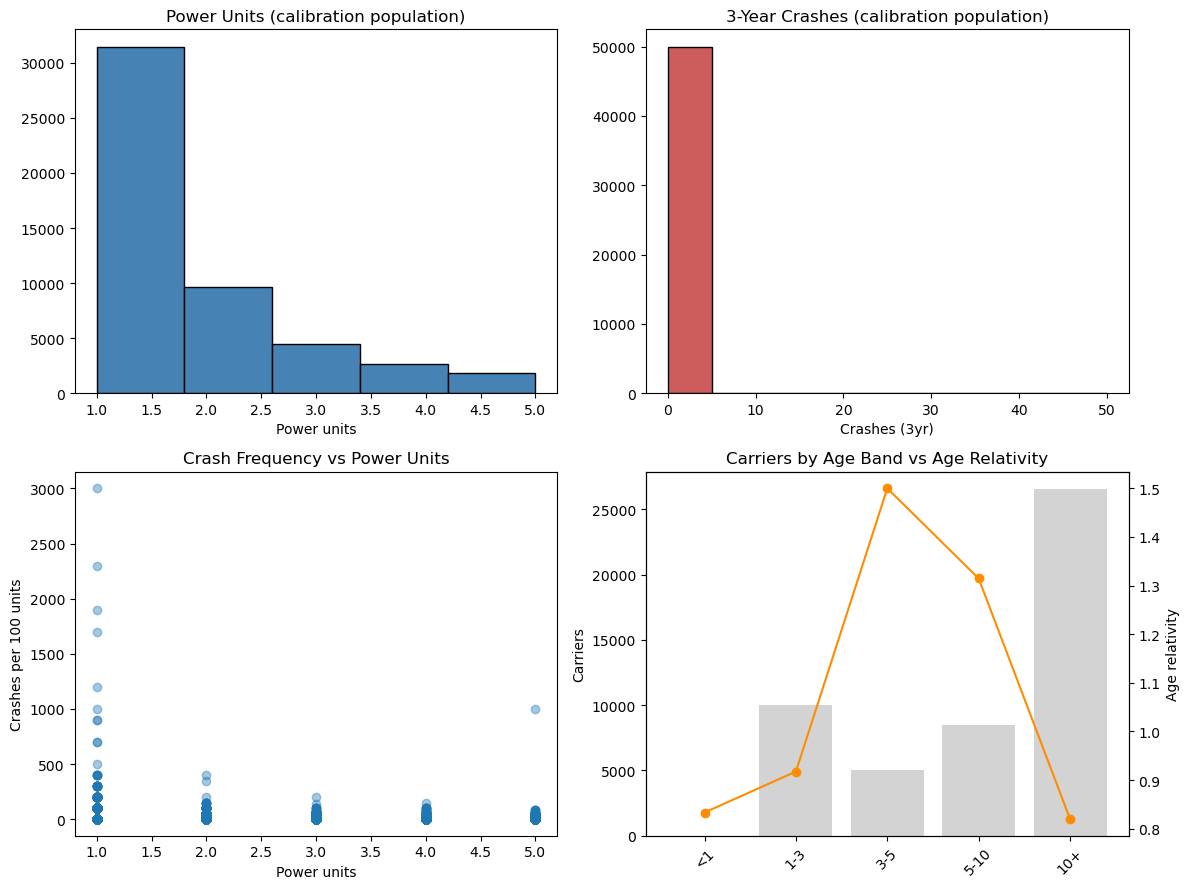

In [48]:
# Trends & Analysis - basic charts

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Power units and 3yr crashes -- the shape portfolio_frequency is calibrated on
axes[0, 0].hist(calibration["power_units"], bins=5, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Power Units (calibration population)")
axes[0, 0].set_xlabel("Power units")

axes[0, 1].hist(calibration["crashes_3yr"], bins=10, color="indianred", edgecolor="black")
axes[0, 1].set_title("3-Year Crashes (calibration population)")
axes[0, 1].set_xlabel("Crashes (3yr)")

# 2. Crash frequency vs power units -- do small fleets really look noisier?
axes[1, 0].scatter(calibration["power_units"], calibration["crash_frequency_per_100_units"], alpha=0.4)
axes[1, 0].set_title("Crash Frequency vs Power Units")
axes[1, 0].set_xlabel("Power units")
axes[1, 0].set_ylabel("Crashes per 100 units")

# 3. Carrier counts by age band next to the age relativity
ax2 = axes[1, 1].twinx()
axes[1, 1].bar(age_stats["age_band"].astype(str), age_stats["carriers"], color="lightgray")
ax2.plot(age_stats["age_band"].astype(str), age_stats["relativity"], color="darkorange", marker="o")
axes[1, 1].set_title("Carriers by Age Band vs Age Relativity")
axes[1, 1].set_ylabel("Carriers")
ax2.set_ylabel("Age relativity")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
#Power units: the target market is heavily concentrated in very small fleets
#3-year crashes: most carriers have zero crashes
#Crash frequency vs power units: individual experience is extremely volatile